# Underwater Garbage Detection YOLOv10
### Detect and classify underwater waste objects using YOLOv10


---

## Project Overview

This notebook implements a complete **object detection pipeline** for identifying underwater garbage using **YOLOv10**, a state-of-the-art real-time object detector. The model is trained to locate and classify **15 distinct categories of marine waste** (e.g., plastic bags, bottles, fishing nets, tyres, cans) inside underwater images.

YOLOv10 improves over previous YOLO generations by eliminating the need for Non-Maximum Suppression (NMS) post-processing through an end-to-end dual-label assignment strategy, resulting in faster inference with competitive accuracy.

---

## Dataset

The **Underwater Garbage** dataset contains approximately 5,000 annotated images split across three subsets:

| Split | Images | Purpose |
|---|---|---|
| `train/` | 3,628 | Used to update model weights during training |
| `valid/` | 1,001 | Used after each epoch to measure generalisation and save `best.pt` |
| `test/`  |   478 | Held-out set — touched only in Section 8 for final evaluation |

Labels are stored in **YOLO format**: one `.txt` file per image, each line containing `class_id x_center y_center width height` (all normalised to 0–1 relative to image dimensions).

---

## Notebook Structure

| Section | What it does |
|---|---|
| **0** | Sets dataset paths and patches `data.yaml` so Ultralytics can locate all images |
| **0b** | Configures Intel CPU optimisations (IPEX / thread tuning) for faster CPU training |
| **1** | Verifies all required Python packages are installed; auto-installs missing ones |
| **2** | Imports all libraries and resolves GPU/CPU device |
| **3** | Loads `data.yaml`, counts annotations per class, displays dataset statistics |
| **4** | Displays 12 random training images with their ground-truth bounding boxes |
| **5** | Validates the YOLO-format dataset; plots the class-frequency bar chart |
| **5b** | Builds an oversampled training list to counteract class imbalance |
| **5c** | Wipes the previous run so training restarts clean with the new settings |
| **6** | Configures all training hyper-parameters; detects whether to resume or start fresh |
| **7** | Launches training with per-epoch checkpoint saving to `d:/Project/checkpoints/` |
| **7b** | Manually saves a timestamped snapshot of `best.pt` |
| **8** | Evaluates `best.pt` on the test split; reports mAP, Precision, Recall, F1 |
| **9** | Plots training/validation loss curves and confusion matrix |
| **10** | Runs batch inference on all test images and displays annotated results |
| **11** | Single-image inference with side-by-side annotated image + bar chart |
| **12** | Gradio web interface — upload any image and get live detections in a browser |

---

## How to Run (Full Training Pipeline)

1. Ensure the dataset is at `d:/Project/Underwater_garbage/` (edit `LOCAL_DATASET_ROOT` in Section 0 if your path differs)
2. Run **Section 1** to verify all required packages are installed
3. Run all remaining sections in order (top to bottom)
4. Trained weights are saved automatically to `d:/Project/runs/` and backed up to `d:/Project/checkpoints/`

---

## ⚡ Quick Inference (No Training Required)

Use this path if you already have trained checkpoints and only want to run predictions:

1. Run the one-time environment setup in a terminal:
   ```powershell
   Set-ExecutionPolicy -Scope Process -ExecutionPolicy Bypass; .\setup_test_env.ps1
   ```
2. Select the **`Python (venv_test)`** kernel in VS Code (bottom-right corner)
3. Run only: **Section 0** → **Section 2** → **Section 11** (or Section 12 for the Gradio UI)
4. In Section 11, update `TEST_IMAGE_PATH` to the full path of your image

All pre-trained checkpoints are loaded automatically from `d:/Project/checkpoints/`.


## Section 0 — Environment & Path Setup

**Run this cell first before any other cell.**

### What this cell does

1. **Declares path variables** — `LOCAL_DATASET_ROOT` points to the `Underwater_garbage` folder on your machine, and `LOCAL_PROJECT` is where Ultralytics saves training run artefacts (weights, metrics CSVs, plots). Edit these two variables if your dataset lives elsewhere.

2. **Validates the dataset root** — If the folder does not exist, a clear `FileNotFoundError` is raised immediately rather than failing silently deep inside training.

3. **Patches `data.yaml`** — Ultralytics reads the `path:` key in `data.yaml` to resolve all image and label paths. Every time you move the project folder or run it on a new machine, this stale path would cause training to fail. This cell reads the YAML file, overwrites the `path:` field with the current absolute path (using forward slashes, which work on both Windows and Linux), and writes it back — so training always finds the correct files regardless of where the dataset is stored.

> **Why use forward slashes on Windows?**  
> Ultralytics internally processes paths using Python's `pathlib`, which normalises forward and back slashes. Using forward slashes in the YAML avoids any edge-case parsing issues on Windows when the YAML is read by a subprocess or a Docker container.


In [1]:
import os
import yaml as _yaml
from pathlib import Path

# ── Local paths — edit these if your layout differs ──────────────────────────
LOCAL_DATASET_ROOT = Path("d:/Project/Underwater_garbage")
LOCAL_PROJECT      = "d:/Project/runs"

DATASET_ROOT = LOCAL_DATASET_ROOT
PROJECT      = LOCAL_PROJECT

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"\n✗ Dataset not found at: {DATASET_ROOT}\n"
        "  → Make sure the 'Underwater_garbage' folder is at d:/Project/Underwater_garbage/\n"
        "  → Or edit LOCAL_DATASET_ROOT above to the correct path."
    )

# ── Patch data.yaml 'path' field ──────────────────────────────────────────────
# Ultralytics reads the 'path:' key to resolve image / label paths.
# We always overwrite it with the current absolute path so there are no stale references.
_yaml_path = DATASET_ROOT / "data.yaml"
with open(_yaml_path, "r") as _f:
    _cfg = _yaml.safe_load(_f)

_cfg["path"] = str(DATASET_ROOT).replace("\\", "/")

with open(_yaml_path, "w") as _f:
    _yaml.dump(_cfg, _f, default_flow_style=False, allow_unicode=True, sort_keys=False)

print(f"Environment       : Local (Windows)")
print(f"Dataset root      : {DATASET_ROOT}")
print(f"Runs dir          : {PROJECT}")
print(f"data.yaml patched : path = {_cfg['path']}")
print(f"Dataset exists    : {DATASET_ROOT.exists()}")


Environment       : Local (Windows)
Dataset root      : d:\Project\Underwater_garbage
Runs dir          : d:/Project/runs
data.yaml patched : path = d:/Project/Underwater_garbage
Dataset exists    : True


## Section 0b — Fast Training Environment (Intel CPU Optimisation)



### Prerequisites

Switch the VS Code kernel to **`Python (venv_fast - IPEX)`** before running this cell (shown in the bottom-right of the VS Code window). If that kernel does not appear, run the setup script once from a terminal:

```powershell
Set-ExecutionPolicy -Scope Process -ExecutionPolicy Bypass; .\setup_fast_env.ps1
```


In [2]:
import os, sys

# ── 1. Thread tuning -- must be set BEFORE torch is imported ──────────────────
_N_CORES = os.cpu_count() or 1          # 12 on your machine
os.environ["OMP_NUM_THREADS"]        = str(_N_CORES)
os.environ["MKL_NUM_THREADS"]        = str(_N_CORES)
os.environ["OPENBLAS_NUM_THREADS"]   = str(_N_CORES)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(_N_CORES)
os.environ["NUMEXPR_NUM_THREADS"]    = str(_N_CORES)
print(f"Thread env vars set to {_N_CORES} cores")

# ── 2. PyTorch intra / inter-op threads ───────────────────────────────────────
import torch
torch.set_num_threads(_N_CORES)
try:
    torch.set_num_interop_threads(max(1, _N_CORES // 2))
except RuntimeError:
    pass   # Already set (cell re-run) -- silently ignore
print(f"torch intra-op threads : {torch.get_num_threads()}")
print(f"torch inter-op threads : {torch.get_num_interop_threads()}")

# ── 3. IPEX on Python <= 3.12 / torch.compile on 3.13+ ───────────────────────
IPEX_AVAILABLE    = False
COMPILE_AVAILABLE = False
_py_minor = sys.version_info.minor
_py_major = sys.version_info.major

if _py_major == 3 and _py_minor <= 12:
    try:
        import intel_extension_for_pytorch as ipex
        IPEX_AVAILABLE = True
        print(f"IPEX {ipex.__version__} loaded -- AVX-512/BF16/AMX optimisations active")
    except ImportError:
        print("IPEX not found -- install via setup_fast_env.ps1 with Python 3.10-3.12")
else:
    # Python 3.13+ -- use torch.compile() instead
    try:
        _test = torch.compile(lambda x: x)   # quick smoke test
        COMPILE_AVAILABLE = True
        print(f"Python {_py_major}.{_py_minor}: torch.compile() available (Inductor backend)")
    except Exception as _e:
        print(f"torch.compile not available: {_e}")

# ── 4. Fast-training hyper-parameter overrides ────────────────────────────────
# These are picked up automatically by Section 6.
import platform as _platform
FAST_BATCH       = 8      # up from 4  (12 cores handle 8 comfortably)
# On Windows, num_workers > 0 in a Jupyter notebook causes multiprocessing spawn issues.
FAST_WORKERS     = 0 if _platform.system() == 'Windows' else 4
FAST_CACHE       = 'ram'  # cache dataset in RAM -- eliminates per-epoch disk I/O
FAST_AMP         = False  # True = BF16 (safe on Intel; requires IPEX or PyTorch 2.3+)

print(f"\nFast-training overrides:")
print(f"  BATCH    : {FAST_BATCH}   (was 4)")
print(f"  WORKERS  : {FAST_WORKERS}   (0 = Windows safe)")
print(f"  CACHE    : {FAST_CACHE}")
print(f"  compile  : {COMPILE_AVAILABLE}")
print(f"\nReady -- proceed to Section 1 (or skip to Section 6 if packages are installed)")


Thread env vars set to 12 cores
torch intra-op threads : 12
torch inter-op threads : 6
Python 3.13: torch.compile() available (Inductor backend)

Fast-training overrides:
  BATCH    : 8   (was 4)
  WORKERS  : 0   (0 = Windows safe)
  CACHE    : ram
  compile  : True

Ready -- proceed to Section 1 (or skip to Section 6 if packages are installed)


## Section 1 — Install & Verify Required Libraries

### What this cell does

This cell checks that every Python package required by the notebook is installed and meets the minimum version constraint. It uses `importlib.import_module()` to attempt importing each package and captures the version string. Packages that are missing or too old are collected in a `missing` list and then installed in a single `pip install` call at the end.

### Key Packages and Their Roles

| Package | Role in this notebook |
|---|---|
| `torch` / `torchvision` | Deep learning framework — provides the neural network operations, GPU acceleration (CUDA), and automatic differentiation used by YOLOv10 |
| `ultralytics` (≥ 8.2.0) | Official Ultralytics library; provides the `YOLO` class for loading, training, validating, and running inference with YOLOv10 models. Version 8.2.0 introduced YOLOv10 support; 8.3+ removed the `fl_gamma` training parameter |
| `opencv-python` (cv2) | Image loading, colour-space conversion (BGR ↔ RGB), bounding-box drawing, and text rendering on images |
| `matplotlib` | Plotting training curves, class-distribution bar charts, and visualising annotated images inside the notebook |
| `pandas` | Tabular data handling — reading `results.csv` (epoch-by-epoch metrics) and building per-class metric DataFrames |
| `Pillow` (PIL) | Auxiliary image loading used by some Ultralytics augmentation pipelines |
| `seaborn` | Enhanced statistical plots (used for confusion-matrix heatmaps) |
| `tqdm` | Progress bars for loops such as iterating over label files |
| `pyyaml` | Reading and writing `data.yaml` — the dataset configuration file Ultralytics requires |

### Why the version check matters

Ultralytics changed the training API between 8.2 and 8.3 (specifically removing `fl_gamma`). The check uses `packaging.version.Version` for a proper semantic-version comparison so that, for example, `8.2.100` is not rejected as older than `8.2.0`.

> **After installing missing packages**, restart the Jupyter kernel and re-run from Section 0 so that the newly installed packages are available in the current Python process.


In [3]:
# ── Verify all required packages are installed ────────────────────────────────
import importlib, sys, subprocess

required = {
    "torch"       : "torch",
    "torchvision" : "torchvision",
    "ultralytics" : "ultralytics>=8.2.0",
    "cv2"         : "opencv-python",
    "matplotlib"  : "matplotlib",
    "pandas"      : "pandas",
    "PIL"         : "Pillow",
    "seaborn"     : "seaborn",
    "tqdm"        : "tqdm",
    "yaml"        : "pyyaml",
}

missing = []
for module, pkg in required.items():
    try:
        m = importlib.import_module(module)
        ver = getattr(m, "__version__", "ok")
        if module == "ultralytics":
            try:
                from packaging.version import Version
                if Version(ver) < Version("8.2.0"):
                    print(f"  ⚠  ultralytics {ver} is too old — YOLOv10 requires >=8.2.0")
                    missing.append("ultralytics>=8.2.0")
                    continue
            except ImportError:
                pass
        print(f"  ✓  {pkg:<30s} {ver}")
    except ImportError:
        print(f"  ✗  {pkg:<30s} NOT FOUND")
        missing.append(pkg)

if missing:
    print(f"\nInstalling missing/outdated packages: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + missing + ["-q"])
    print("Done — please RESTART the kernel and re-run from Section 0.")
else:
    print("\n✓ All packages are ready!")

print(f"\nPython : {sys.version}")


  ✓  torch                          2.10.0+cpu
  ✓  torchvision                    0.25.0+cpu
  ✓  ultralytics>=8.2.0             8.4.21
  ✓  opencv-python                  4.13.0
  ✓  matplotlib                     3.10.8
  ✓  pandas                         3.0.1
  ✓  Pillow                         12.1.1
  ✓  seaborn                        0.13.2
  ✓  tqdm                           4.67.3
  ✓  pyyaml                         6.0.3

✓ All packages are ready!

Python : 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]


## Section 2 — Import Required Libraries & Resolve Paths

### What this cell does

This cell imports all the Python libraries needed throughout the notebook in one place, so later cells do not need to repeat imports. It also resolves file-system paths for each dataset split and detects whether a CUDA GPU is available.

### Key Imports Explained

- **`pathlib.Path`** — used everywhere for cross-platform path manipulation instead of raw strings, avoiding Windows backslash issues.
- **`cv2` (OpenCV)** — handles image reading (`cv2.imread`), colour conversion (`cv2.cvtColor`), bounding-box drawing (`cv2.rectangle`), and text overlay (`cv2.putText`).
- **`matplotlib` / `matplotlib.patches`** — generates all in-notebook figures; `patches.Rectangle` draws YOLO bounding boxes as matplotlib artists (useful for high-quality figure export).
- **`numpy`** — array mathematics — used for confusion-matrix arithmetic and computing mean confidence values.
- **`pandas`** — reads `results.csv` (epoch metrics log written by Ultralytics) and constructs per-class metric tables rendered with `df.to_string()`.
- **`seaborn`** — provides enhanced plotting styles and the confusion-matrix palette.
- **`torch`** — imported here primarily to detect CUDA availability via `torch.cuda.is_available()`.
- **`yaml`** — reads `data.yaml` to extract class names and dataset structure.
- **`ultralytics.YOLO`** — the single entry point for loading a YOLO model for training, validation, or inference.
- **`tqdm`** — adds progress bars to any Python loop (e.g., iterating over thousands of label files to count class occurrences).

### Path Setup

The following path constants are derived from `DATASET_ROOT` (set in Section 0) and are used throughout the notebook:

| Variable | Points to |
|---|---|
| `DATA_YAML` | `data.yaml` — Ultralytics dataset config |
| `TRAIN_IMG` | Training images folder |
| `TRAIN_LBL` | Training label `.txt` files folder |
| `VALID_IMG` | Validation images folder |
| `TEST_IMG`  | Test images folder |

### Device Detection

`DEVICE = "cuda" if torch.cuda.is_available() else "cpu"` — this single variable is passed to every `.train()`, `.val()`, and `.predict()` call so that the code runs identically on both GPU and CPU machines without modification.


In [4]:
import os
import random
import warnings
from pathlib import Path

import cv2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO

warnings.filterwarnings("ignore")

# ── Paths (DATASET_ROOT and PROJECT come from Section 0) ─────────────────────
# Fallback: if Section 0 was skipped, default to local Windows paths
if "DATASET_ROOT" not in globals():
    DATASET_ROOT = Path("d:/Project/Underwater_garbage")
    PROJECT      = "d:/Project/runs"

DATA_YAML  = DATASET_ROOT / "data.yaml"
TRAIN_IMG  = DATASET_ROOT / "train" / "images"
TRAIN_LBL  = DATASET_ROOT / "train" / "labels"
VALID_IMG  = DATASET_ROOT / "valid"  / "images"
TEST_IMG   = DATASET_ROOT / "test"   / "images"

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
print(f"Dataset  : {DATASET_ROOT}")


PyTorch  : 2.10.0+cpu
Device   : cpu
Dataset  : d:\Project\Underwater_garbage


## Section 3 — Load and Explore the Dataset

### What this cell does

Before training, it is essential to understand the dataset — how many images exist per split, how annotations are distributed across classes, and whether there is significant class imbalance that needs to be addressed. This section produces a statistical summary that informs decisions made in Section 5b (oversampling).

### Steps Performed

1. **Load `data.yaml`** — Parses the Ultralytics dataset config using PyYAML to extract:
   - `nc` — total number of classes
   - `names` — ordered list (or dict) of class name strings
   
   The `names` field can be either a plain list or an `{int: str}` dict depending on the YAML format. Both are handled uniformly.

2. **Count images and labels per split** — For each of the three splits (`train`, `valid`, `test`), the code globs the `images/` and `labels/` subdirectories and counts files. A mismatch between image and label counts can indicate missing annotations.

3. **Count annotations per class across the training set** — Every `.txt` label file in `TRAIN_LBL` is opened. Each line represents one bounding-box annotation; the first token is the integer class ID. A frequency dictionary `class_counts` is built by tallying those IDs. This reveals:
   - Which classes are **rare** (few annotations) — these are candidates for oversampling
   - Which classes are **dominant** — the model risks ignoring rare classes if no mitigation is applied

4. **Display a ranked table** (`df_dist`) — The per-class count table is sorted by annotation count descending and printed. The ratio of the highest to lowest count (the **imbalance ratio**, computed in Section 5b) can easily exceed 50× on real-world datasets, which is why oversampling and copy-paste augmentation are applied.


In [5]:
# ── Dataset statistics ────────────────────────────────────────────────────────
with open(DATA_YAML, "r") as f:
    cfg = yaml.safe_load(f)

CLASS_NAMES = list(cfg["names"].values()) if isinstance(cfg["names"], dict) else cfg["names"]
NC = cfg["nc"]

splits = {
    "train": (DATASET_ROOT / "train"),
    "valid": (DATASET_ROOT / "valid"),
    "test" : (DATASET_ROOT / "test"),
}

stats = {}
for split, root in splits.items():
    imgs = list((root / "images").glob("*.*"))
    lbls = list((root / "labels").glob("*.txt"))
    stats[split] = {"images": len(imgs), "labels": len(lbls)}

df_stats = pd.DataFrame(stats).T
print("=== Dataset Split Summary ===")
print(df_stats.to_string())
print(f"\nNumber of classes : {NC}")
print(f"Class names       : {CLASS_NAMES}")

# ── Class distribution in training set ────────────────────────────────────────
class_counts = {i: 0 for i in range(NC)}
for lbl_file in TRAIN_LBL.glob("*.txt"):
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_counts[int(parts[0])] += 1

df_dist = pd.DataFrame({
    "class_id"  : list(class_counts.keys()),
    "class_name": CLASS_NAMES,
    "count"     : list(class_counts.values()),
}).sort_values("count", ascending=False)

print("\n=== Training Annotation Class Distribution ===")
print(df_dist.to_string(index=False))


=== Dataset Split Summary ===
       images  labels
train    3628    3628
valid    1001    1007
test      478     501

Number of classes : 15
Class names       : ['bottle', 'can', 'cap', 'cigarette', 'cup', 'fishing-line', 'glove', 'mask', 'other-colors', 'peel', 'plastic-bag', 'plastic-box', 'plastic-jar', 'plastic-gloves', 'unknown']

=== Training Annotation Class Distribution ===
 class_id     class_name  count
       14        unknown   2274
        0         bottle   1445
        5   fishing-line   1172
        9           peel   1135
       10    plastic-bag    932
        8   other-colors    531
        4            cup    339
        2            cap    268
       11    plastic-box    176
        7           mask    173
        3      cigarette    137
        1            can    124
        6          glove     56
       12    plastic-jar     26
       13 plastic-gloves     14


## Section 4 — Visualise Sample Training Images

### What this cell does

This section visually verifies that the dataset is loaded correctly by rendering **12 randomly sampled training images** alongside their **ground-truth bounding boxes**. Looking at annotated samples before training is a critical sanity check — it confirms that:

- Class labels map to the right objects
- Bounding boxes are correctly positioned (not offset, flipped, or scaled wrongly)
- Image quality and diversity are as expected (varied lighting, angles, occlusions)

### How the `draw_boxes` helper works

The `draw_boxes(img_path, lbl_path, class_names, ax)` function:

1. **Reads the image** with OpenCV (`cv2.imread`) and converts it from BGR (OpenCV default) to RGB (matplotlib default) using `cv2.cvtColor`.
2. **Parses the YOLO label file** — each line is space-separated: `class_id x_center y_center width height`. All coordinates are normalised (0 to 1), so they are multiplied by the image's pixel width/height to obtain absolute pixel coordinates.
   - Top-left corner: `(xc - w/2) * img_width`, `(yc - h/2) * img_height`
3. **Draws bounding boxes** as `matplotlib.patches.Rectangle` artists — this preserves the original pixel colours (no cv2 drawing artefacts) and produces publication-quality figures.
4. **Assigns colours** using the `tab20` colormap — a 20-colour palette where each class consistently receives the same colour, making different boxes easy to distinguish at a glance.
5. **Overlays the class name** as a text label above each box, with a semi-transparent black background for legibility over bright regions.

### Output

A 3 × 4 grid of annotated images is displayed. Each re-run produces a different random sample from the ~3,600 training images.


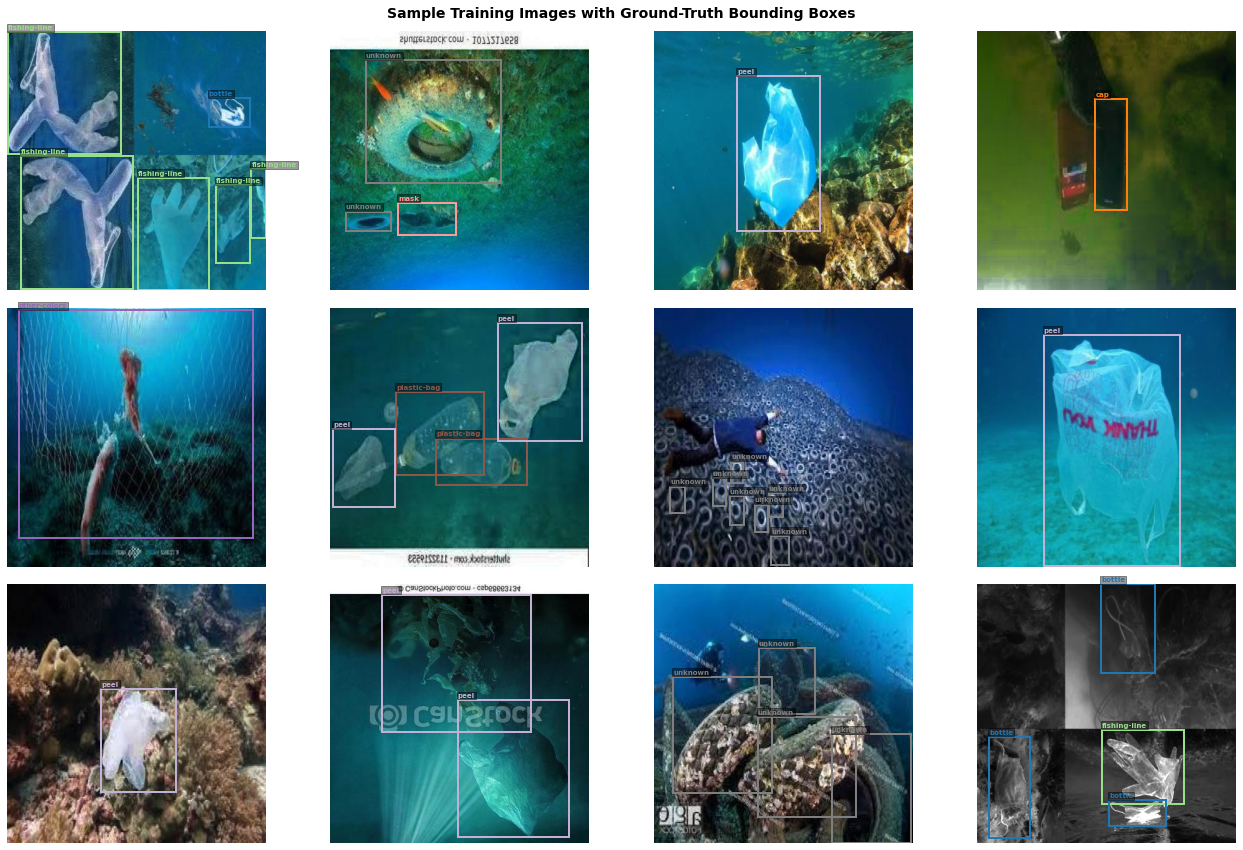

In [6]:
def draw_boxes(img_path: Path, lbl_path: Path, class_names, ax):
    """Draw YOLO bounding boxes on an image."""
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # ── Colormap (compatible with matplotlib ≥3.7 and ≥3.9) ──────────────────
    _cmap  = matplotlib.colormaps["tab20"]
    colors = [_cmap(i / 20.0) for i in range(20)]   # list of 20 RGBA tuples

    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls, xc, yc, bw, bh = int(parts[0]), *[float(p) for p in parts[1:5]]
                x1 = int((xc - bw / 2) * w)
                y1 = int((yc - bh / 2) * h)
                bw_px, bh_px = int(bw * w), int(bh * h)
                c = colors[cls % 20]
                rect = patches.Rectangle((x1, y1), bw_px, bh_px,
                                         linewidth=2, edgecolor=c, facecolor="none")
                ax.add_patch(rect)
                ax.text(x1, y1 - 4,
                        class_names[cls] if cls < len(class_names) else str(cls),
                        color=c, fontsize=7, fontweight="bold",
                        bbox=dict(facecolor="black", alpha=0.4, pad=1))
    ax.imshow(img)
    ax.axis("off")


# ── Plot 12 random training samples with annotations ─────────────────────────
img_list = sorted(TRAIN_IMG.glob("*.*"))
sample_imgs = random.sample(img_list, min(12, len(img_list)))

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle("Sample Training Images with Ground-Truth Bounding Boxes",
             fontsize=14, fontweight="bold")

for ax, img_path in zip(axes.flatten(), sample_imgs):
    lbl_path = TRAIN_LBL / (img_path.stem + ".txt")
    draw_boxes(img_path, lbl_path, CLASS_NAMES, ax)

plt.tight_layout()
plt.show()


## Section 5 — Verify Dataset & Visualise Class Distribution

### What this cell does

The dataset is already in YOLO format (images and `.txt` labels stored side-by-side), so no format conversion is needed. This section:

1. **Prints the full contents of `data.yaml`** so you can verify the paths, number of classes, and class names are correct before training begins.

2. **Spot-checks image–label pairing** — iterates over the first 20 training images and confirms that a corresponding label `.txt` file exists in `TRAIN_LBL`. A missing label file means the model has no supervision signal for that image; a large number of missing labels is a data-preparation error that must be fixed before training.

3. **Plots a colour-coded bar chart** of annotation counts per class using the sorted `df_dist` table computed in Section 3. Each bar corresponds to one of the 15 waste categories; the bar height shows how many bounding-box annotations exist for that class in the training set.

### Why this matters

The bar chart directly reveals class imbalance. For example, if "plastic bag" has 2,000 annotations while "metal pot" has only 40, the ratio is 50×. Without mitigation, the model's loss is dominated by the common classes and it learns to ignore rare ones. The visual makes the severity easy to communicate and motivates the oversampling strategy in Section 5b.

### Reading the chart

- **Tall bars** = dominant classes — the model will see plenty of examples.
- **Short bars** = rare classes — prone to low recall; addressed by inverse-frequency oversampling in Section 5b.
- The **count labels** on top of each bar show the exact number for precise reference when tuning the oversampling cap.


=== data.yaml contents ===
path: d:/Project/Underwater_garbage
train: train/images
val: valid/images
test: test/images
nc: 15
names:
  0: bottle
  1: can
  2: cap
  3: cigarette
  4: cup
  5: fishing-line
  6: glove
  7: mask
  8: other-colors
  9: peel
  10: plastic-bag
  11: plastic-box
  12: plastic-jar
  13: plastic-gloves
  14: unknown

✓ All checked training images have corresponding label files.


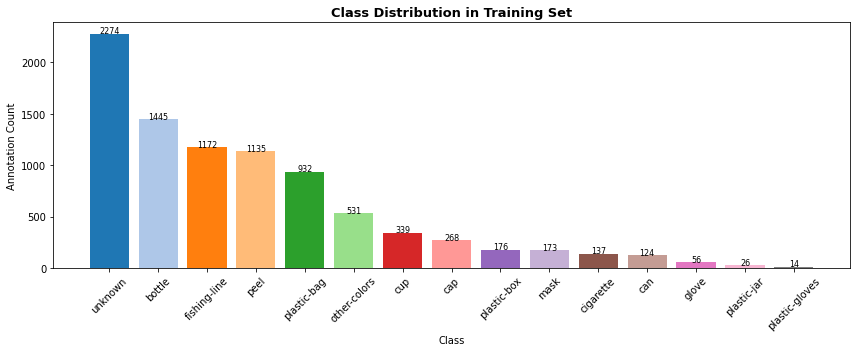

In [7]:
# The dataset is already in YOLO format (images + labels side by side).
# We verify the data.yaml file and display its contents.

print("=== data.yaml contents ===")
with open(DATA_YAML) as f:
    print(f.read())

# Verify image-label pairing for the training split
missing_labels = []
for img_path in sorted(TRAIN_IMG.glob("*.*"))[:20]:          # check first 20
    lbl = TRAIN_LBL / (img_path.stem + ".txt")
    if not lbl.exists():
        missing_labels.append(img_path.name)

if missing_labels:
    print(f"WARNING: {len(missing_labels)} images have no label file!")
else:
    print("✓ All checked training images have corresponding label files.")

# ── Class-distribution bar chart ─────────────────────────────────────────────
# Use colormaps API compatible with matplotlib ≥3.7 and ≥3.9
_cmap      = matplotlib.colormaps["tab20"]
bar_colors = [_cmap(i / 20.0) for i in range(NC)]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(df_dist["class_name"], df_dist["count"], color=bar_colors)
ax.set_title("Class Distribution in Training Set", fontsize=13, fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Annotation Count")
ax.tick_params(axis="x", rotation=45)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5, str(int(bar.get_height())),
            ha="center", fontsize=8)
plt.tight_layout()
plt.show()


## Section 5b — Class Imbalance Mitigation

Highly imbalanced datasets cause the model to over-predict common classes and under-detect rare ones. This section implements two complementary strategies applied **before and during** training.

### Strategy 1: Inverse-Frequency Oversampling (Pre-training)

For each class `c`, an inverse-frequency weight is computed as:

$$w_c = \frac{\text{total annotations}}{NC \times \text{count}_c}$$

Weights are then mean-normalised so the average weight equals 1.0. The weight for each training image is taken as the maximum weight across all classes it contains (i.e., an image containing a rare class gets the high weight).

Each image is then **repeated** `round(weight)` times in the training file list, capped at `OVERSAMPLE_CAP = 8×` to prevent the effective dataset size from exploding. The resulting shuffled list is written to `train_oversampled.txt`. A new `data_balanced.yaml` is created that points to this file instead of the original image folder, and Section 7 uses this balanced YAML automatically.

**Effect:** Rare-class images appear more often per epoch, so the model receives proportionally more gradient signal for those classes without any change to the model architecture.

### Strategy 2: Copy-Paste Augmentation (During Training)

`copy_paste=0.1` in the training kwargs (Section 7) instructs Ultralytics to randomly extract objects from one image and paste them onto another during data loading. This synthetically creates new training examples for rare classes at essentially zero extra cost.

### Why Not Focal Loss `fl_gamma`?

`fl_gamma` was a training parameter in Ultralytics ≤ 8.2 that scaled the cross-entropy loss to down-weight well-classified examples. It was **removed in Ultralytics 8.3+** — focal-loss weighting is now fixed internally. The `FL_GAMMA` variable is retained in this notebook only to choose the oversampling **aggressiveness tier**:

| Imbalance Ratio | Tier | Oversampling behaviour |
|---|---|---|
| < 10× | Mild | Light repetition of rare images |
| 10–50× | Moderate | Moderate repetition |
| > 50× | Aggressive | Repeat up to the 8× cap |

### Output

Two side-by-side bar charts show annotation counts **before** and **after** oversampling for every class, with the effective imbalance ratio printed for both. A lower ratio after oversampling confirms the mitigation is working.


Imbalance ratio (heaviest ÷ lightest class frequency): 162.4×

Per-class inverse-frequency weights  (mean-normalised to 1.0):
  [ 0] bottle                     cnt= 1445  w= 0.06  █
  [ 1] can                        cnt=  124  w= 0.72  █
  [ 2] cap                        cnt=  268  w= 0.33  █
  [ 3] cigarette                  cnt=  137  w= 0.66  █
  [ 4] cup                        cnt=  339  w= 0.26  █
  [ 5] fishing-line               cnt= 1172  w= 0.08  █
  [ 6] glove                      cnt=   56  w= 1.60  ██
  [ 7] mask                       cnt=  173  w= 0.52  █
  [ 8] other-colors               cnt=  531  w= 0.17  █
  [ 9] peel                       cnt= 1135  w= 0.08  █
  [10] plastic-bag                cnt=  932  w= 0.10  █
  [11] plastic-box                cnt=  176  w= 0.51  █
  [12] plastic-jar                cnt=   26  w= 3.45  ███
  [13] plastic-gloves             cnt=   14  w= 6.41  ██████
  [14] unknown                    cnt= 2274  w= 0.04  █

Imbalance severity level:

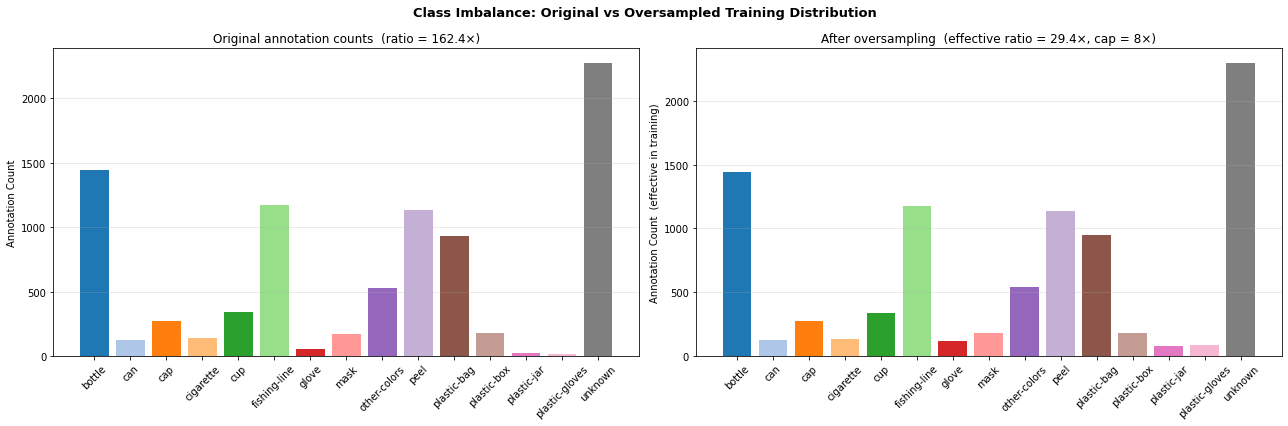


✓ Section 5b complete — BALANCED_YAML is ready for Section 6 / 7.


In [6]:
import numpy as _np

# ── 1. Per-image class membership ─────────────────────────────────────────────
img_class_map = {}   # stem → list[int]
for lbl_file in TRAIN_LBL.glob("*.txt"):
    cls_ids = []
    with open(lbl_file) as _f:
        for line in _f:
            parts = line.strip().split()
            if parts:
                cls_ids.append(int(parts[0]))
    if cls_ids:
        img_class_map[lbl_file.stem] = cls_ids

# ── 2. Inverse-frequency class weights (mean-normalised) ─────────────────────
_total_ann = sum(class_counts.values())
_class_inv = {
    c: (_total_ann / (NC * class_counts[c])) if class_counts[c] > 0 else 0.0
    for c in range(NC)
}
_mean_w   = _np.mean([v for v in _class_inv.values() if v > 0])
class_w   = {c: v / _mean_w for c, v in _class_inv.items()}

_valid_w        = [v for v in class_w.values() if v > 0]
imbalance_ratio = max(_valid_w) / min(_valid_w)

print(f"Imbalance ratio (heaviest ÷ lightest class frequency): {imbalance_ratio:.1f}×\n")
print("Per-class inverse-frequency weights  (mean-normalised to 1.0):")
for c in range(NC):
    bar    = "█" * min(20, max(1, round(class_w[c])))
    suffix = "…" if class_w[c] > 20 else ""
    print(f"  [{c:2d}] {CLASS_NAMES[c]:<25s}  cnt={class_counts[c]:>5d}  w={class_w[c]:5.2f}  {bar}{suffix}")

# ── 3. Auto-select focal-loss gamma (informational only) ─────────────────────
# fl_gamma was removed in Ultralytics 8.3+ and is not passed to model.train().
# The value is kept here only to guide the oversampling aggressiveness decision.
#   < 10×  → fl_gamma = 1.0  (mild)
#  10–50×  → fl_gamma = 1.5  (moderate)
#   > 50×  → fl_gamma = 2.0  (severe)
if imbalance_ratio < 10:
    FL_GAMMA = 1.0
elif imbalance_ratio < 50:
    FL_GAMMA = 1.5
else:
    FL_GAMMA = 2.0

print(f"\nImbalance severity level: fl_gamma proxy = {FL_GAMMA}  (imbalance ratio = {imbalance_ratio:.1f}×)")

# ── 4. Build oversampled training file list ────────────────────────────────────
# Each image is repeated round(max_class_weight) times.
# Cap is set higher (8×) to give enough headroom for severely rare classes
# without exploding dataset size.  Images with only majority-class objects keep 1 copy.
OVERSAMPLE_CAP  = 8
_stem_to_img    = {p.stem: p for p in TRAIN_IMG.glob("*.*")}
oversampled_paths = []
_over_counts      = {c: 0 for c in range(NC)}

for stem, cls_ids in img_class_map.items():
    if stem not in _stem_to_img:
        continue
    img_w   = max(class_w.get(c, 1.0) for c in cls_ids)
    repeats = min(OVERSAMPLE_CAP, max(1, round(img_w)))
    oversampled_paths.extend(
        [str(_stem_to_img[stem]).replace("\\", "/")] * repeats
    )
    for c in cls_ids:
        _over_counts[c] += repeats

random.shuffle(oversampled_paths)

OVERSAMPLE_TXT = DATASET_ROOT / "train_oversampled.txt"
OVERSAMPLE_TXT.write_text("\n".join(oversampled_paths) + "\n")

print(f"\nOriginal training images   : {len(img_class_map)}")
print(f"Oversampled list size      : {len(oversampled_paths)}"
      f"  ({len(oversampled_paths)/len(img_class_map):.1f}× expansion)")
print(f"Saved to                   : {OVERSAMPLE_TXT}")

# Verify paths in txt file are accessible
_missing_paths = sum(1 for p in oversampled_paths if not Path(p).exists())
if _missing_paths:
    print(f"\n  ⚠  WARNING: {_missing_paths} paths in train_oversampled.txt do NOT exist on disk!")
    print(f"     → Re-run Section 0 to ensure DATASET_ROOT is set correctly, then re-run this cell.")
else:
    print(f"✓ All {len(oversampled_paths)} paths in train_oversampled.txt verified on disk.")

# ── 5. Create balanced data.yaml ──────────────────────────────────────────────
with open(DATA_YAML) as _f:
    _cfg_bal = yaml.safe_load(_f)

_cfg_bal["train"] = str(OVERSAMPLE_TXT).replace("\\", "/")
BALANCED_YAML = DATASET_ROOT / "data_balanced.yaml"

with open(BALANCED_YAML, "w") as _f:
    yaml.dump(_cfg_bal, _f, default_flow_style=False, allow_unicode=True, sort_keys=False)

print(f"Balanced data.yaml         : {BALANCED_YAML}")

# ── 6. Effective imbalance ratio after oversampling ───────────────────────────
_over_valid = [v for v in _over_counts.values() if v > 0]
_over_ratio = max(_over_valid) / min(_over_valid) if len(_over_valid) > 1 else 1.0
print(f"\nEffective imbalance ratio  : {imbalance_ratio:.1f}× → {_over_ratio:.1f}× after oversampling")

# ── 7. Visualise: original vs oversampled annotation distribution ─────────────
_cmap2      = matplotlib.colormaps["tab20"]
_orig_cnts  = [class_counts[c]  for c in range(NC)]
_over_cnts  = [_over_counts[c]  for c in range(NC)]
_bar_colors = [_cmap2(c / 20.0) for c in range(NC)]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Class Imbalance: Original vs Oversampled Training Distribution",
             fontsize=13, fontweight="bold")

ax0.bar(CLASS_NAMES, _orig_cnts, color=_bar_colors)
ax0.set_title(f"Original annotation counts  (ratio = {imbalance_ratio:.1f}×)")
ax0.set_ylabel("Annotation Count")
ax0.tick_params(axis="x", rotation=45)

ax1.bar(CLASS_NAMES, _over_cnts, color=_bar_colors)
ax1.set_title(f"After oversampling  (effective ratio = {_over_ratio:.1f}×, cap = {OVERSAMPLE_CAP}×)")
ax1.set_ylabel("Annotation Count  (effective in training)")
ax1.tick_params(axis="x", rotation=45)

for _ax in (ax0, ax1):
    _ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Section 5b complete — BALANCED_YAML is ready for Section 6 / 7.")


## Section 5c — Reset Run for Fresh Training

### Purpose

Run this cell **once** before starting a brand-new training run that should incorporate the imbalance-mitigation settings (oversampling + copy-paste augmentation) from the very first epoch.

Without this reset, if `last.pt` already exists in the run directory from a prior session, Section 6 will detect it and set `RESUME = True` — meaning training will continue from where it left off using the **old training configuration** (before imbalance mitigation was added). The oversampling and augmentation changes would only apply to future epochs of the resumed run, not from epoch 0.

### What Gets Deleted

| File / Folder | Reason |
|---|---|
| `runs/<RUN_NAME>/weights/` | Contains `last.pt` (the resume trigger) and `best.pt`. Deleting this forces Section 6 to start a fresh run |
| `runs/<RUN_NAME>/results.csv` | Epoch-by-epoch metrics log. Deleted so the epoch counter resets to 0 and training curves start cleanly |

### What Is Never Touched

`d:/Project/checkpoints/` — all timestamped `.pt` snapshots are **kept safe**. This directory is listed at the end of the cell so you can confirm your previous best checkpoint is still there.

### When to Skip This Cell

- If you want to **resume** an interrupted run (e.g., the machine crashed at epoch 45 out of 100) — do not run this cell; Section 6 will automatically resume.
- If you want to **continue** training beyond the original epoch target (e.g., train 50 more epochs on top of a completed 100-epoch run) — again, do not run this cell; Section 6 detects the "completed" state and runs a continuation.


In [9]:
import shutil as _shutil_reset

# ── Paths to clear (RUN_NAME comes from Section 6 if already run, else build it) ──
_model_size_r = globals().get("MODEL_SIZE", "m")
_run_name_r   = globals().get("RUN_NAME",   f"yolov10{_model_size_r}_underwater_garbage_v2")
_project_r    = globals().get("PROJECT",    "d:/Project/runs")

_weights_dir  = Path(_project_r) / _run_name_r / "weights"
_results_csv  = Path(_project_r) / _run_name_r / "results.csv"

_deleted = []

# ── Delete weights folder (last.pt + best.pt) ─────────────────────────────────
if _weights_dir.exists():
    _shutil_reset.rmtree(str(_weights_dir))
    _deleted.append(str(_weights_dir))
    print(f"  ✓ Deleted weights dir  : {_weights_dir}")
else:
    print(f"  –  Weights dir not found (already clean): {_weights_dir}")

# ── Delete results.csv (epoch counter used by Section 6) ─────────────────────
if _results_csv.exists():
    _results_csv.unlink()
    _deleted.append(str(_results_csv))
    print(f"  ✓ Deleted results.csv  : {_results_csv}")
else:
    print(f"  –  results.csv not found (already clean): {_results_csv}")

print()
if _deleted:
    print("✓ Run directory cleared — Section 6 will now start a FRESH training run.")
else:
    print("✓ Nothing to clear — run directory was already clean.")

print("\nCheckpoints in backup dir (kept safe):")
_ckpt_dir = Path(_project_r).parent / "checkpoints"
_snaps = sorted(_ckpt_dir.glob(f"{_run_name_r}*.pt"))
if _snaps:
    for _s in _snaps:
        print(f"  ★  {_s.name}  ({_s.stat().st_size // 1024} KB)")
else:
    print("  (none)")


  –  Weights dir not found (already clean): d:\Project\runs\yolov10m_underwater_garbage_v2\weights
  –  results.csv not found (already clean): d:\Project\runs\yolov10m_underwater_garbage_v2\results.csv

✓ Nothing to clear — run directory was already clean.

Checkpoints in backup dir (kept safe):
  (none)


## Section 6 — Configure YOLOv10 Model & Hyper-Parameters

### What this cell does

This section prepares everything the training cell (Section 7) needs: it selects hyper-parameters, resolves the model weights to load, and determines whether to start a **fresh run**, **resume** an interrupted run, or do a **continuation run** (training more epochs on top of a fully completed one).

### Model Selection

`MODEL_SIZE = "m"` selects **YOLOv10-Medium**, a good balance between accuracy and speed for CPU/entry-level GPU training. Available variants are `n` (nano), `s` (small), `m` (medium), `b` (base), `l` (large), `x` (extra-large).

### Key Hyper-Parameters

| Parameter | Value | Meaning |
|---|---|---|
| `EPOCHS` | 100 | Total training epochs targeted across all runs |
| `IMGSZ` | 640 | Input image size (pixels). All images are resized/letterboxed to 640×640 |
| `BATCH` | 4 (or 8 with IPEX) | Number of images per gradient update step |
| `LR0` | 0.01 | Initial learning rate |
| `LRF` | 0.01 | Final LR factor; with cosine decay the LR ends at `LR0 × LRF` |
| `PATIENCE` | 20 | Early-stopping patience — training halts if mAP does not improve for 20 consecutive epochs |

### Checkpoint Priority Logic

The cell inspects the file system to choose the starting point:

1. **`last.pt` exists AND is incomplete** (`epochs_done < EPOCHS`) → `RESUME = True` — Ultralytics resumes training seamlessly from the exact epoch, optimizer state, and learning-rate schedule stored in the checkpoint.
2. **`last.pt` exists AND is complete** (`epochs_done == EPOCHS`) → `RESUME = False`, `EPOCHS_TO_TRAIN = EPOCHS - epochs_done` — a *continuation* run starts using the fine-tuned weights as the pretrained starting point.
3. **No `last.pt`, but a local `.pt` file exists** → loads it as pretrained weights; fresh run starts from epoch 0.
4. **Nothing found** → downloads `yolov10m.pt` from the Ultralytics model zoo; fresh run.

### Auto-Resume Details

The checkpoint metadata is read directly from the `.pt` file (`torch.load`) because `results.csv` can be reset to zero when a continuation run begins, making it an unreliable epoch counter. The checkpoint's embedded `epoch` key is always correct.

### Backup Directory

`CKPT_BACKUP_DIR = d:/Project/checkpoints/` is created here (if it doesn't exist) and used by the per-epoch callback in Section 7 to store rolling `_best.pt` / `_last.pt` copies and immutable timestamped snapshots.


In [5]:

# ── YOLOv10 model variants ────────────────────────────────────────────────────
MODEL_SIZE = "m"

# ── Hyperparameters ───────────────────────────────────────────────────────────
EPOCHS    = 100            # total target epochs (50 already done → 50 more will run)
IMGSZ     = 640
BATCH     = globals().get("FAST_BATCH",   4)
WORKERS   = globals().get("FAST_WORKERS", 0)
CACHE     = globals().get("FAST_CACHE",   False)
LR0       = 0.01
LRF       = 0.01
PATIENCE  = 20
RUN_NAME  = f"yolov10{MODEL_SIZE}_underwater_garbage_v2"

# ── Weight paths ──────────────────────────────────────────────────────────────
LAST_WEIGHTS = Path(PROJECT) / RUN_NAME / "weights" / "last.pt"
BEST_WEIGHTS = Path(PROJECT) / RUN_NAME / "weights" / "best.pt"

# ── Backup directory ──────────────────────────────────────────────────────────
CKPT_BACKUP_DIR  = Path(PROJECT).parent / "checkpoints"
CKPT_BACKUP_DIR.mkdir(parents=True, exist_ok=True)
CKPT_BACKUP_BEST = CKPT_BACKUP_DIR / f"{RUN_NAME}_best.pt"
CKPT_BACKUP_LAST = CKPT_BACKUP_DIR / f"{RUN_NAME}_last.pt"

# ── Local pre-downloaded weights ─────────────────────────────────────────────
_LOCAL_WEIGHTS = Path("d:/Project") / f"yolov10{MODEL_SIZE}.pt"

# ── Count completed epochs (results.csv) ─────────────────────────────────────
_results_csv = Path(PROJECT) / RUN_NAME / "results.csv"
_epochs_done_csv = 0
if _results_csv.exists():
    try:
        _df_ck           = pd.read_csv(_results_csv)
        _epochs_done_csv = len(_df_ck)
    except Exception as _ck_e:
        print(f"  WARNING: could not read results.csv ({_ck_e})")

# ── Read checkpoint metadata directly (more reliable than results.csv) ────────
# results.csv can be zeroed when a continuation run starts; the checkpoint itself
# always holds the true number of completed epochs.
_ckpt_epoch_idx   = -1   # 0-indexed last completed epoch stored in the .pt file
_ckpt_orig_epochs = -1   # epoch target the checkpoint was trained with
_ckpt_is_complete = False

if LAST_WEIGHTS.exists():
    try:
        _peek             = torch.load(str(LAST_WEIGHTS), map_location="cpu", weights_only=False)
        _ckpt_epoch_idx   = _peek.get("epoch", -1)
        _ckpt_orig_epochs = (_peek.get("train_args") or {}).get("epochs", -1)
        if _ckpt_orig_epochs > 0 and (_ckpt_epoch_idx + 1) >= _ckpt_orig_epochs:
            _ckpt_is_complete = True
        del _peek
    except Exception as _pe:
        print(f"  INFO: could not inspect checkpoint metadata ({_pe})")

# Use checkpoint epoch as the ground-truth for epochs done (CSV may be reset)
_epochs_done = _ckpt_epoch_idx + 1 if _ckpt_epoch_idx >= 0 else _epochs_done_csv
print(f"Epochs done (checkpoint): {_epochs_done}  |  CSV rows: {_epochs_done_csv}")
if _ckpt_orig_epochs > 0:
    print(f"Checkpoint original target: {_ckpt_orig_epochs} epochs  |  "
          f"Complete: {_ckpt_is_complete}")

# ── Decide: resume / continuation / fresh start ───────────────────────────────
if LAST_WEIGHTS.exists():
    model = YOLO(str(LAST_WEIGHTS))
    if _epochs_done >= EPOCHS:
        RESUME          = False
        EPOCHS_TO_TRAIN = EPOCHS
        print(f"\nlast.pt fully done ({_epochs_done}/{EPOCHS}) — starting FRESH run "
              f"(last.pt used as pretrained weights)")
    elif _ckpt_is_complete:
        # Checkpoint finished its original run but we want more epochs.
        RESUME          = False
        EPOCHS_TO_TRAIN = EPOCHS - _epochs_done
        print(f"\nCheckpoint complete at its original {_ckpt_orig_epochs}-epoch target "
              f"({_epochs_done} epochs done total).")
        print(f"  → CONTINUATION run: {EPOCHS_TO_TRAIN} MORE epochs "
              f"(epochs {_epochs_done + 1}–{EPOCHS})")
    else:
        RESUME          = True
        EPOCHS_TO_TRAIN = EPOCHS
        print(f"\nCheckpoint ({_epochs_done}/{EPOCHS} epochs done) — RESUMING from: {LAST_WEIGHTS}")
elif _LOCAL_WEIGHTS.exists():
    RESUME, EPOCHS_TO_TRAIN = False, EPOCHS
    model = YOLO(str(_LOCAL_WEIGHTS))
    print(f"\nNo checkpoint — loading LOCAL pretrained weights: {_LOCAL_WEIGHTS}")
else:
    RESUME, EPOCHS_TO_TRAIN = False, EPOCHS
    model = YOLO(f"yolov10{MODEL_SIZE}.pt")
    print(f"\nNo checkpoint — downloading YOLOv10-{MODEL_SIZE.upper()} pretrained weights")

print(f"\nModel         : YOLOv10-{MODEL_SIZE.upper()}")
print(f"Epochs target : {EPOCHS}  (this run: {EPOCHS_TO_TRAIN})")
print(f"Img size      : {IMGSZ}")
print(f"Batch         : {BATCH}")
print(f"Workers       : {WORKERS}")
print(f"Cache         : {CACHE}")
print(f"Device        : {DEVICE}")
print(f"Threads       : {torch.get_num_threads()} intra / {torch.get_num_interop_threads()} inter-op")
print(f"Resume        : {RESUME}")
print(f"Weights dir   : {Path(PROJECT) / RUN_NAME / 'weights'}")


Epochs done (checkpoint): 50  |  CSV rows: 50
Checkpoint original target: 50 epochs  |  Complete: False

Checkpoint (50/100 epochs done) — RESUMING from: d:\Project\runs\yolov10m_underwater_garbage_v2\weights\last.pt

Model         : YOLOv10-M
Epochs target : 100  (this run: 100)
Img size      : 640
Batch         : 8
Workers       : 0
Cache         : ram
Device        : cpu
Threads       : 12 intra / 6 inter-op
Resume        : True
Weights dir   : d:\Project\runs\yolov10m_underwater_garbage_v2\weights


## Section 7 — Train the YOLOv10 Model

### What this cell does

This is the core training section. It registers a per-epoch checkpoint callback, assembles all training keyword arguments, and calls `model.train()` (or `model.train(resume=True)` for a resumed run).

### Per-Epoch Checkpoint Callback (`_epoch_backup`)

Ultralytics saves `last.pt` and `best.pt` inside the **run directory** (`runs/<RUN_NAME>/weights/`). If that folder is accidentally deleted, or if the run directory is cleaned for a fresh start, those weights are gone. The `_epoch_backup` callback is registered with `model.add_callback("on_fit_epoch_end", ...)` and fires after every single epoch to:

- Copy `last.pt` and `best.pt` to `d:/Project/checkpoints/` as `<RUN_NAME>_last.pt` and `<RUN_NAME>_best.pt` (rolling backups — overwritten each epoch)
- Detect when a **new best** is found (by comparing the `mtime` of `best.pt` — it only changes when Ultralytics overwrites it with a better checkpoint)
- Save an **immutable timestamped snapshot** `<RUN_NAME>_best_epoch{N}_{HHMMSS}.pt` whenever a new best is detected — these snapshots accumulate and are never overwritten

### Training Data

The cell first checks whether `BALANCED_YAML` (created in Section 5b) points to a valid `train_oversampled.txt`. If valid, the balanced YAML is used as the training data source; otherwise it falls back to the original `data.yaml`. This ensures oversampling is applied if Section 5b was run.

### Key Training Arguments Explained

| Argument | Value | Effect |
|---|---|---|
| `optimizer = "AdamW"` | — | Adaptive optimiser with weight decay decoupled from the learning-rate gradient — generally more stable than SGD for detection |
| `cos_lr = True` | — | Cosine learning-rate annealing — LR decreases smoothly from `LR0` to `LR0 × LRF` following a cosine curve rather than a step schedule |
| `warmup_epochs = 3.0` | — | Linearly ramps LR and momentum from near-zero for the first 3 epochs to stabilise early gradient updates |
| `label_smoothing = 0.1` | — | Replaces hard 0/1 classification targets with 0.05/0.95, reducing overconfidence and improving calibration |
| `mosaic = 1.0` | — | Mosaic augmentation: combines 4 images into one at every batch — substantially increases positional and scale diversity |
| `mixup = 0.10` | — | Blends two images and their labels together with a random mixing ratio — improves generalisation |
| `copy_paste = 0.1` | — | Extracts object instances from random images and pastes them onto the current image — key for rare-class augmentation |
| `erasing = 0.4` | — | Random rectangular erasing applied to images — forces the model to be robust to partial occlusion |
| `box = 7.5`, `cls = 0.5`, `dfl = 1.5` | — | Loss weights balancing localisation (box), classification, and distribution focal loss contributions |

### CPU Training Note

Training on CPU is significantly slower than GPU (roughly 10–30 minutes per epoch for YOLOv10-M at 640px on a 12-core desktop CPU). Reduce `EPOCHS` in Section 6 if a full run is too slow, or use Part 0b (IPEX) for 2–4× speed improvement.


In [12]:

import shutil as _shutil
import datetime as _dt

# ── Per-epoch checkpoint save + new-best detection ────────────────────────────
_prev_best_mtime = [None]

def _epoch_backup(trainer):
    epoch    = getattr(trainer, "epoch", "?")
    ts       = _dt.datetime.now().strftime("%H:%M:%S")
    _last_src = Path(trainer.last) if getattr(trainer, "last", None) else LAST_WEIGHTS
    _best_src = Path(trainer.best) if getattr(trainer, "best", None) else BEST_WEIGHTS
    CKPT_BACKUP_DIR.mkdir(parents=True, exist_ok=True)
    saved = []
    new_best = False

    if _best_src.exists():
        cur_mtime = _best_src.stat().st_mtime
        if _prev_best_mtime[0] is None or cur_mtime > _prev_best_mtime[0]:
            if _prev_best_mtime[0] is not None:
                new_best = True
            _prev_best_mtime[0] = cur_mtime

    for src, dst, label in [
        (_last_src, CKPT_BACKUP_LAST, "last"),
        (_best_src, CKPT_BACKUP_BEST, "best"),
    ]:
        if src.exists():
            try:
                _shutil.copy2(str(src), str(dst))
                kb = dst.stat().st_size // 1024
                saved.append(f"{label}.pt ({kb} KB)")
            except Exception as e:
                print(f"  [Epoch {epoch}] WARNING: could not backup {label}.pt -- {e}")
        else:
            if not (label == "best" and epoch == 0):
                print(f"  [Epoch {epoch}] WARNING: source not found: {src}")

    if new_best and _best_src.exists():
        snap_name = f"{RUN_NAME}_best_epoch{epoch:03d}_{_dt.datetime.now().strftime('%H%M%S')}.pt"
        snap_dst  = CKPT_BACKUP_DIR / snap_name
        try:
            _shutil.copy2(str(_best_src), str(snap_dst))
            kb = snap_dst.stat().st_size // 1024
            print(f"  ★  [Epoch {epoch:>3d} | {ts}] NEW BEST saved: {snap_name} ({kb} KB)")
        except Exception as e:
            print(f"  [Epoch {epoch}] WARNING: could not save new-best snapshot -- {e}")

    if saved:
        marker = "★ NEW BEST  " if new_best else "            "
        print(f"  {marker}[Epoch {epoch:>3d} | {ts}]  last.pt ✓  best.pt ✓  → {CKPT_BACKUP_DIR}")

model.add_callback("on_fit_epoch_end", _epoch_backup)

# ── Training data source: prefer balanced yaml (oversampled), fall back to data.yaml ─
_TRAIN_DATA = globals().get("BALANCED_YAML", DATA_YAML)

# Validate that the oversampled txt file referenced by BALANCED_YAML exists on disk
if _TRAIN_DATA != DATA_YAML:
    _txt_ref = None
    try:
        import yaml as _y_check
        with open(_TRAIN_DATA) as _f_check:
            _bal_cfg = _y_check.safe_load(_f_check)
        _txt_ref = Path(_bal_cfg.get("train", ""))
        if not _txt_ref.exists():
            print(f"  ⚠  train_oversampled.txt not found at: {_txt_ref}")
            print(f"     → Falling back to data.yaml.  Re-run Section 5b to regenerate.")
            _TRAIN_DATA = DATA_YAML
        else:
            print(f"✓ Oversampled training list verified: {_txt_ref}")
    except Exception as _ve:
        print(f"  ⚠  Could not validate BALANCED_YAML ({_ve}) — using data.yaml")
        _TRAIN_DATA = DATA_YAML

print(f"Training data  : {_TRAIN_DATA}")
print(f"Imbalance mitigation: inverse-frequency oversampling (cap={globals().get('OVERSAMPLE_CAP', 8)}×)")
print(f"  (fl_gamma was removed in Ultralytics 8.3+; cls loss focal weighting is fixed internally)")

# ── Epochs to run this session (handles continuation after a completed run) ───
_epochs_this_run = globals().get("EPOCHS_TO_TRAIN", EPOCHS)
print(f"Epochs this run: {_epochs_this_run}  (of {EPOCHS} total target)")

# ── Shared train kwargs ────────────────────────────────────────────────────────
_train_kwargs = dict(
    data        = str(_TRAIN_DATA),
    epochs      = _epochs_this_run,    # <-- uses remaining epochs for continuation runs
    imgsz       = IMGSZ,
    batch       = BATCH,
    workers     = WORKERS,
    cache       = CACHE,
    lr0         = LR0,
    lrf         = LRF,
    patience    = PATIENCE,
    device      = DEVICE,
    project     = PROJECT,
    name        = RUN_NAME,
    exist_ok    = True,
    pretrained  = True,
    save        = True,
    save_period = -1,
    optimizer       = "AdamW",
    cos_lr          = True,
    weight_decay    = 0.0005,
    warmup_epochs   = 3.0,
    warmup_momentum = 0.8,
    warmup_bias_lr  = 0.1,
    box             = 7.5,
    cls             = 0.5,
    dfl             = 1.5,
    label_smoothing = 0.1,
    # ── Augmentation ─────────────────────────────────────────────────────────
    flipud      = 0.5,
    fliplr      = 0.5,
    mosaic      = 1.0,
    mixup       = 0.10,
    copy_paste  = 0.1,
    degrees     = 10,
    translate   = 0.1,
    scale       = 0.5,
    shear       = 2.0,
    perspective = 0.0001,
    hsv_h       = 0.015,
    hsv_s       = 0.7,
    hsv_v       = 0.4,
    erasing     = 0.4,
)

# ── Train ─────────────────────────────────────────────────────────────────────
if RESUME:
    print(f"Resuming training from: {LAST_WEIGHTS}")
    try:
        results = model.train(resume=True)
    except AssertionError as _ae:
        print(f"\n  ⚠  Resume blocked: {_ae}")
        print(f"  → Falling back to a continuation run using last.pt as pretrained weights.\n")
        results = model.train(**_train_kwargs)
else:
    print(f"Starting {'continuation' if _epochs_this_run < EPOCHS else 'fresh'} "
          f"training run on device: {DEVICE}")
    results = model.train(**_train_kwargs)

# ── Refresh weight paths after training ───────────────────────────────────────
BEST_WEIGHTS = Path(PROJECT) / RUN_NAME / "weights" / "best.pt"
LAST_WEIGHTS = Path(PROJECT) / RUN_NAME / "weights" / "last.pt"

print(f"\n{'='*60}")
print(f"  Training finished.")
print(f"{'='*60}")
print(f"  Run weights  │  best : {BEST_WEIGHTS}")
print(f"               │  last : {LAST_WEIGHTS}")
print(f"  Backup dir   │  {CKPT_BACKUP_DIR}")
print(f"  best exists  : {BEST_WEIGHTS.exists()}")
print(f"  last exists  : {LAST_WEIGHTS.exists()}")
print(f"  Timestamped snapshots in backup dir:")
for _snap in sorted(CKPT_BACKUP_DIR.glob(f"{RUN_NAME}_best_epoch*.pt")):
    _kb = _snap.stat().st_size // 1024
    print(f"    ★  {_snap.name}  ({_kb} KB)")


✓ Oversampled training list verified: d:\Project\Underwater_garbage\train_oversampled.txt
Training data  : d:\Project\Underwater_garbage\data_balanced.yaml
Imbalance mitigation: inverse-frequency oversampling (cap=8×)
  (fl_gamma was removed in Ultralytics 8.3+; cls loss focal weighting is fixed internally)
Epochs this run: 50  (of 100 total target)
Starting continuation training run on device: cuda
WARNING 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.19  Python-3.11.5 torch-2.1.2+cu118 CUDA:0 (NVIDIA RTX 2000 Ada Generation, 16380MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=d:\Project\Underwater_garbage\data_balanced.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, 

## Section 7b — Save Timestamped Checkpoint Snapshot

### Purpose

The per-epoch callback in Section 7 already backs up `best.pt` and `last.pt` continuously. This cell is a **manual trigger** to save an additional timestamped snapshot — useful to mark the completion of a training run or to create a named milestone that you want to preserve before running more training.

### Checkpoint File Roles

| File | Description | Overwritten? |
|---|---|---|
| `<RUN_NAME>_last.pt` | Rolling backup of the last-epoch checkpoint — always reflects the most recent epoch's state including optimiser parameters and LR schedule | Yes — every epoch by the Section 7 callback |
| `<RUN_NAME>_best.pt` | Rolling backup of the best checkpoint (highest validation mAP seen so far) | Yes — whenever a new best is detected |
| `<RUN_NAME>_best_<timestamp>.pt` | Immutable snapshot created by this cell (and by the Section 7 callback on each new-best epoch) | Never — filename includes the date-time, making every snapshot unique |

### When to Run This Cell

- **After completing a full training run** — to capture the final `best.pt` with a human-readable timestamp before potentially starting another training run that would overwrite the rolling backups.
- **After a checkpoint transfer** — if you copy `best.pt` from another machine, run this cell to register it in the `checkpoints/` directory with a proper timestamp.

### Resuming Training

The cell prints a concise reminder of how to resume: simply re-run Sections 0, 6, and 7. Section 6 automatically detects `last.pt` and sets `RESUME = True`, so training picks up from the exact epoch, learning-rate, and optimiser state stored in that file.


In [12]:
import shutil, datetime

# ── Ensure backup dir exists ──────────────────────────────────────────────────
CKPT_BACKUP_DIR.mkdir(parents=True, exist_ok=True)

# ── Refresh paths in case training updated them ───────────────────────────────
_best = Path(PROJECT) / RUN_NAME / "weights" / "best.pt"
_last = Path(PROJECT) / RUN_NAME / "weights" / "last.pt"

# ── Copy best.pt and last.pt (overwrite rolling backups) ─────────────────────
for src, dst in [(_best, CKPT_BACKUP_BEST), (_last, CKPT_BACKUP_LAST)]:
    if src.exists():
        shutil.copy2(str(src), str(dst))
        size_mb = dst.stat().st_size / 1e6
        print(f"  ✓  {dst.name:<55s}  {size_mb:.1f} MB")
    else:
        print(f"  ⚠  Not found: {src}  (train the model first)")

# ── Timestamped snapshot of best.pt ──────────────────────────────────────────
if _best.exists():
    ts   = datetime.datetime.now().strftime("%Y%m%d_%H%M")
    snap = CKPT_BACKUP_DIR / f"{RUN_NAME}_best_{ts}.pt"
    shutil.copy2(str(_best), str(snap))
    size_mb = snap.stat().st_size / 1e6
    print(f"  ✓  {snap.name:<55s}  {size_mb:.1f} MB  [timestamped snapshot]")

print(f"\n✓ All backups saved to: {CKPT_BACKUP_DIR}")
print("\n─── HOW TO RESUME A TRAINING RUN ────────────────────────────────────")
print("  1. Re-run Section 0 → Section 6 → Section 7")
print(f"  2. Section 6 detects last.pt at: {_last}")
print("     and automatically sets RESUME = True")
print("  3. Training resumes from the exact epoch it stopped")
print("─────────────────────────────────────────────────────────────────────")


  ✓  yolov10m_underwater_garbage_v2_best.pt                   33.5 MB
  ✓  yolov10m_underwater_garbage_v2_last.pt                   33.5 MB
  ✓  yolov10m_underwater_garbage_v2_best_20260305_1516.pt     33.5 MB  [timestamped snapshot]

✓ All backups saved to: d:\Project\checkpoints

─── HOW TO RESUME A TRAINING RUN ────────────────────────────────────
  1. Re-run Section 0 → Section 6 → Section 7
  2. Section 6 detects last.pt at: d:\Project\runs\yolov10m_underwater_garbage_v2\weights\last.pt
     and automatically sets RESUME = True
  3. Training resumes from the exact epoch it stopped
─────────────────────────────────────────────────────────────────────


## Section 8 — Evaluate Model on the Test Set

### What this cell does

This section performs a rigorous final evaluation of the **best checkpoint** (`best.pt` — the one with the highest validation mAP) on the **held-out test split**. The test split has never been seen during training or used for early-stopping decisions, so this gives an unbiased estimate of real-world performance.

### Checkpoint Resolution

The cell searches for `best.pt` in three locations in order of preference:

1. `runs/<RUN_NAME>/weights/best.pt` — primary output of the training run
2. `checkpoints/<RUN_NAME>_best.pt` — rolling backup written by the Section 7 callback
3. Most recent `checkpoints/<RUN_NAME>_best_epoch*.pt` — timestamped snapshot fallback

If none are found, an `AssertionError` is raised with clear instructions.

### Metrics Explained

| Metric | Formula | Interpretation |
|---|---|---|
| **mAP@0.50** | Mean Average Precision at IoU threshold 0.5 | Primary YOLO metric — measures how accurately boxes are detected and classified at 50% overlap |
| **mAP@0.50:0.95** | Average mAP over IoU thresholds 0.5, 0.55, …, 0.95 | More strict; penalises imprecise localisation |
| **Mean Precision** | TP / (TP + FP) averaged over classes | Of all detections made, what fraction are correct |
| **Mean Recall** | TP / (TP + FN) averaged over classes | Of all real objects, what fraction did the model find |
| **F1 Score** | 2 × P × R / (P + R) | Harmonic mean of Precision and Recall — balances both |
| **Overall Accuracy** | ΣTP / Σ Ground-Truth objects (from confusion matrix) | Fraction of ground-truth objects that were correctly identified |

### Per-Class Metrics

`best_model.val()` returns per-class Arrays `test_metrics.box.ap50`, `.p`, `.r` indexed by class. These are assembled into a Pandas DataFrame, sorted by AP@50 descending, and printed. A grouped bar chart then visualises Precision, Recall, and F1 for every class side by side, with mean reference lines for quick comparison.

### `CLASS_NAMES` Assignment

`CLASS_NAMES = best_model.names` extracts the `{int: str}` class-name dictionary embedded in the loaded model weights. This is the authoritative mapping used by all downstream cells.


In [8]:

# ── Load BEST model for evaluation ───────────────────────────────────────────
# Priority:   1. <runs>/<RUN_NAME>/weights/best.pt   (primary run output)
#             2. <checkpoints>/<RUN_NAME>_best.pt    (per-epoch backup copy)
#             3. Latest timestamped best_epoch*.pt   (immutable snapshots)
# last.pt is intentionally NOT used here — it is only the resume checkpoint,
# NOT necessarily the highest-mAP model.

# Refresh paths in case Section 7 just finished

_eval_best = Path(PROJECT) / RUN_NAME / "weights" / "best.pt"

if _eval_best.exists():
    BEST_WEIGHTS = _eval_best
    _source = "run weights dir"
elif CKPT_BACKUP_BEST.exists():
    BEST_WEIGHTS = CKPT_BACKUP_BEST
    _source = "backup dir (rolling copy)"
else:
    # Last resort: pick the most recent timestamped snapshot
    _snaps = sorted(CKPT_BACKUP_DIR.glob(f"{RUN_NAME}_best_epoch*.pt"))
    if _snaps:
        BEST_WEIGHTS = _snaps[-1]
        _source = f"timestamped snapshot ({BEST_WEIGHTS.name})"
    else:
        BEST_WEIGHTS = None
        _source = "NOT FOUND"

assert BEST_WEIGHTS is not None and BEST_WEIGHTS.exists(), (
    "best.pt not found in any location.\n"
    f"  Checked: {Path(PROJECT) / RUN_NAME / 'weights' / 'best.pt'}\n"
    f"           {CKPT_BACKUP_BEST}\n"
    f"           {CKPT_BACKUP_DIR / (RUN_NAME + '_best_epoch*.pt')}\n"
    "Run Section 7 to train the model first."
)

print(f"{'='*60}")
print(f"  Evaluating with BEST MODEL (highest validation mAP)")
print(f"{'='*60}")
print(f"  Source : {_source}")
print(f"  File   : {BEST_WEIGHTS}")
print(f"  Size   : {BEST_WEIGHTS.stat().st_size / 1e6:.2f} MB")
print()

best_model = YOLO(str(BEST_WEIGHTS))
CLASS_NAMES = best_model.names   # {0: 'classA', 1: 'classB', ...}

# Run validation on the test split using the best model
test_metrics = best_model.val(
    data    = str(DATA_YAML),
    split   = "test",
    imgsz   = IMGSZ,
    device  = DEVICE,
    verbose = True,
)

# ── Overall metrics ───────────────────────────────────────────────────────────
_mp  = test_metrics.box.mp   # mean precision
_mr  = test_metrics.box.mr   # mean recall
_f1  = (2 * _mp * _mr / (_mp + _mr)) if (_mp + _mr) > 0 else 0.0

# Overall accuracy from confusion matrix:
# Each matrix cell [i,j] = number of objects with true class i predicted as class j.
# The last row/col is the "background" (FP/FN bin).
# Accuracy = correctly classified objects / all annotated objects (ignore background col).
_cm_matrix = None
_accuracy  = float("nan")
try:
    _cm_matrix = test_metrics.confusion_matrix.matrix   # shape (NC+1, NC+1)
    import numpy as _np2
    _nc1       = _cm_matrix.shape[0]                    # NC + 1
    _tp_sum    = _cm_matrix[:_nc1-1, :_nc1-1].diagonal().sum()   # true positives
    _total_gt  = _cm_matrix[:_nc1-1, :].sum()                    # all ground-truth objects
    _accuracy  = _tp_sum / _total_gt if _total_gt > 0 else float("nan")
except Exception as _e:
    print(f"  (Confusion matrix not available: {_e})")

print(f"\n{'='*60}")
print(f"  Test-Set Results  (best.pt)")
print(f"{'='*60}")
print(f"  mAP@0.50           : {test_metrics.box.map50:.4f}")
print(f"  mAP@0.50:0.95      : {test_metrics.box.map:.4f}")
print(f"  Mean Precision     : {_mp:.4f}")
print(f"  Mean Recall        : {_mr:.4f}")
print(f"  F1 Score           : {_f1:.4f}  (= 2·P·R / (P+R))")
if not (isinstance(_accuracy, float) and _accuracy != _accuracy):   # not NaN
    print(f"  Overall Accuracy   : {_accuracy:.4f}  (TP / all GT objects, from confusion matrix)")

# ── Per-class AP, Precision, Recall, F1 ──────────────────────────────────────
if hasattr(test_metrics.box, "ap_class_index"):
    import numpy as _np3
    _cls_idx = list(test_metrics.box.ap_class_index)
    _ap50    = list(test_metrics.box.ap50)

    # Per-class precision & recall are stored in test_metrics.box.p / .r (arrays)
    _p_arr = list(test_metrics.box.p) if hasattr(test_metrics.box, "p") else [float("nan")] * len(_cls_idx)
    _r_arr = list(test_metrics.box.r) if hasattr(test_metrics.box, "r") else [float("nan")] * len(_cls_idx)
    _f1_arr = [
        (2 * p * r / (p + r)) if (p + r) > 0 else 0.0
        for p, r in zip(_p_arr, _r_arr)
    ]

    df_ap = pd.DataFrame({
        "class"    : [CLASS_NAMES[i] for i in _cls_idx],
        "AP@50"    : [round(v, 4) for v in _ap50],
        "Precision": [round(v, 4) for v in _p_arr],
        "Recall"   : [round(v, 4) for v in _r_arr],
        "F1"       : [round(v, 4) for v in _f1_arr],
    }).sort_values("AP@50", ascending=False)

    print(f"\n  Per-class metrics (sorted by AP@50):")
    print(df_ap.to_string(index=False))

    # ── Per-class bar chart: Precision / Recall / F1 ─────────────────────────
    _classes_sorted = df_ap["class"].tolist()
    _x = _np3.arange(len(_classes_sorted))
    _w = 0.28

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.bar(_x - _w,  df_ap["Precision"].tolist(), _w, label="Precision", color="steelblue")
    ax.bar(_x,       df_ap["Recall"].tolist(),    _w, label="Recall",    color="tomato")
    ax.bar(_x + _w,  df_ap["F1"].tolist(),        _w, label="F1 Score",  color="seagreen")

    ax.set_xticks(_x)
    ax.set_xticklabels(_classes_sorted, rotation=45, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title("Per-Class Precision / Recall / F1  (test split, best.pt)",
                 fontsize=13, fontweight="bold")
    ax.legend()
    ax.axhline(y=_mp, color="steelblue", linestyle="--", linewidth=0.8, alpha=0.6, label=f"Mean P={_mp:.3f}")
    ax.axhline(y=_mr, color="tomato",    linestyle="--", linewidth=0.8, alpha=0.6, label=f"Mean R={_mr:.3f}")
    ax.axhline(y=_f1, color="seagreen",  linestyle="--", linewidth=0.8, alpha=0.6, label=f"Mean F1={_f1:.3f}")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── Summary banner ────────────────────────────────────────────────────────
    print(f"\n{'─'*60}")
    print(f"  SUMMARY")
    print(f"{'─'*60}")
    print(f"  Overall Accuracy : {_accuracy:.2%}" if not (isinstance(_accuracy, float) and _accuracy != _accuracy) else "  Overall Accuracy : N/A")
    print(f"  Mean Precision   : {_mp:.2%}")
    print(f"  Mean Recall      : {_mr:.2%}")
    print(f"  F1 Score         : {_f1:.2%}")
    print(f"  mAP@0.50         : {test_metrics.box.map50:.2%}")
    print(f"{'─'*60}")


  Evaluating with BEST MODEL (highest validation mAP)
  Source : run weights dir
  File   : d:\Project\runs\yolov10m_underwater_garbage_v2\weights\best.pt
  Size   : 33.51 MB

Ultralytics 8.4.21  Python-3.13.7 torch-2.10.0+cpu CPU (12th Gen Intel Core i5-1235U)
YOLOv10m summary (fused): 136 layers, 15,321,853 parameters, 0 gradients, 58.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 276.275.9 MB/s, size: 36.9 KB)
val: Scanning D:\Project\Underwater_garbage\test\labels.cache... 478 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 478/478 125.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 7.6s/it 3:499.5ss
                   all        478        930      0.547       0.45      0.517      0.314
                bottle         21         24      0.853      0.243       0.49       0.36
                   can         13         19      0.461      0.316       0.32       0.13
                   cap       

<Figure size 1600x600 with 1 Axes>


────────────────────────────────────────────────────────────
  SUMMARY
────────────────────────────────────────────────────────────
  Overall Accuracy : 68.70%
  Mean Precision   : 54.72%
  Mean Recall      : 44.96%
  F1 Score         : 49.36%
  mAP@0.50         : 51.72%
────────────────────────────────────────────────────────────


## Section 9 — Visualise Training Metrics

### What this cell does

After training completes, Ultralytics writes a `results.csv` file inside the run directory containing one row per epoch with all training and validation metrics. This section reads that file and generates diagnostic plots to assess training quality, convergence, and overfitting.

### Training Curves

Six sub-plots are generated in a 2 × 3 grid:

| Plot | What it shows | Healthy pattern |
|---|---|---|
| **Box Loss** | Bounding-box regression loss (CIoU / DFL combined) for train and validation | Both curves decrease smoothly and stay close together |
| **Class Loss** | Classification cross-entropy loss for train and validation | Decreases and converges; val loss should not diverge upward |
| **DFL Loss** | Distribution Focal Loss — measures how well the model predicts the distribution of box edges rather than a single point | Decreases similarly to box loss |
| **Precision** | Validation precision across epochs | Should rise and plateau near 0.7–0.9 for a well-trained model |
| **Recall** | Validation recall across epochs | Should rise similarly to precision |
| **mAP@0.50** | Primary detection metric across epochs | Should trend upwards; flattening indicates convergence |

**Diverging train vs. validation loss** (val loss rises while train loss falls) indicates **overfitting** — the model has memorised the training data and stops generalising. Mitigation strategies include increasing dropout, reducing batch size, adding more augmentation, or training with more data.

### Confusion Matrix

Ultralytics generates a confusion matrix image (`confusion_matrix.png` or `confusion_matrix_normalized.png`) inside the run directory during validation. The cell looks for this file and displays it directly. Each cell `[i, j]` in the matrix shows how many objects whose **true class is `i`** were **predicted as class `j`** — the diagonal represents correct detections, and off-diagonal values reveal class confusion (e.g., "plastic bottle" and "glass bottle" being mistaken for each other).


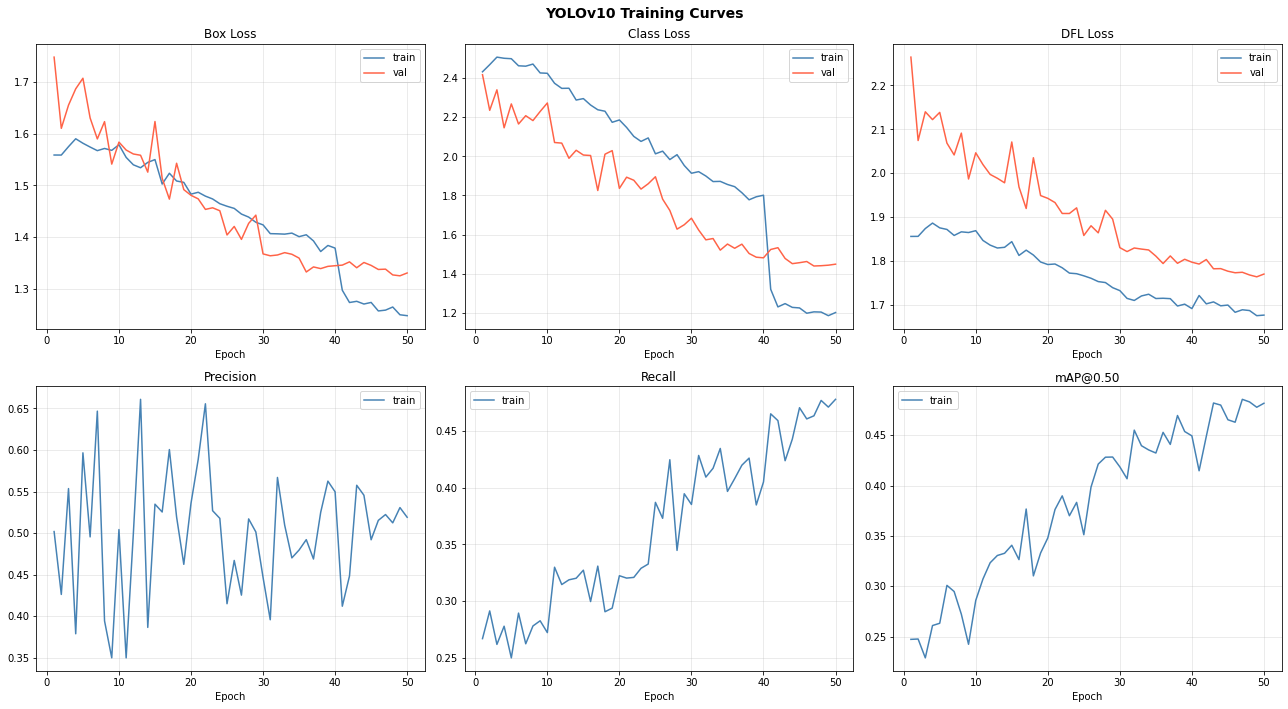

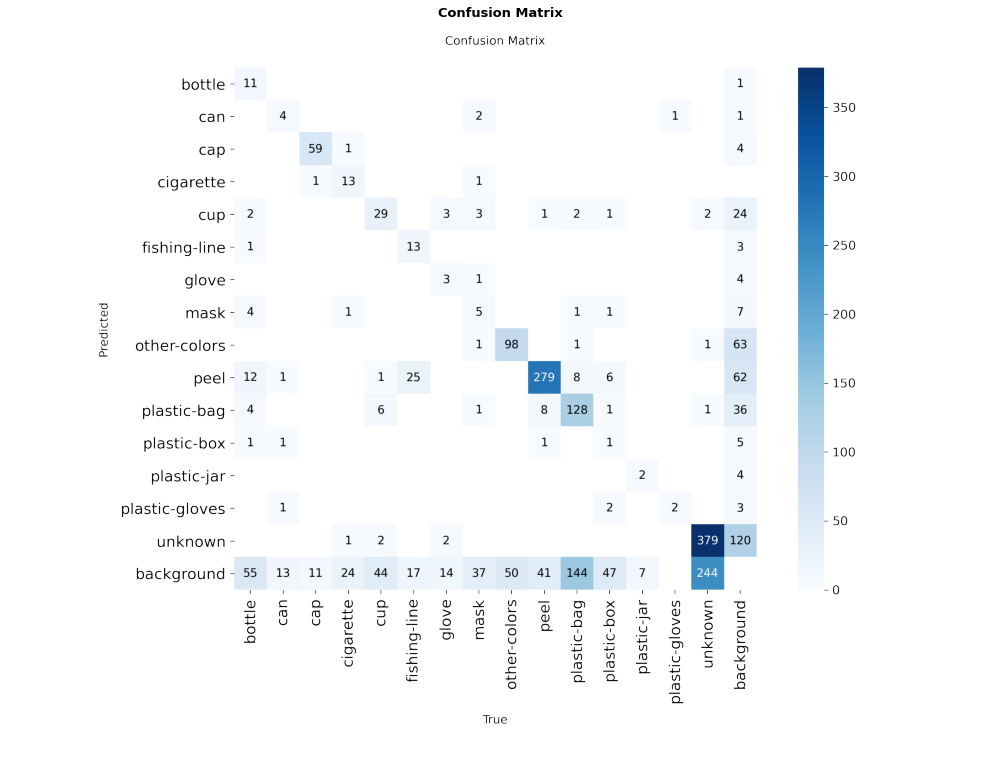

In [15]:
RUN_DIR = Path(PROJECT) / RUN_NAME

# ── 1. Training curves from results.csv ───────────────────────────────────────
csv_path = RUN_DIR / "results.csv"
if csv_path.exists():
    df_res = pd.read_csv(csv_path)
    df_res.columns = df_res.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("YOLOv10 Training Curves", fontsize=14, fontweight="bold")

    pairs = [
        ("train/box_loss", "val/box_loss", "Box Loss"),
        ("train/cls_loss", "val/cls_loss", "Class Loss"),
        ("train/dfl_loss", "val/dfl_loss", "DFL Loss"),
        ("metrics/precision(B)", None, "Precision"),
        ("metrics/recall(B)",    None, "Recall"),
        ("metrics/mAP50(B)",     None, "mAP@0.50"),
    ]
    for ax, (train_col, val_col, title) in zip(axes.flatten(), pairs):
        if train_col in df_res.columns:
            ax.plot(df_res["epoch"], df_res[train_col], label="train", color="steelblue")
        if val_col and val_col in df_res.columns:
            ax.plot(df_res["epoch"], df_res[val_col], label="val", color="tomato")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ── 2. Confusion matrix ───────────────────────────────────────────────────────
cm_img = RUN_DIR / "confusion_matrix.png"
if not cm_img.exists():
    cm_img = RUN_DIR / "confusion_matrix_normalized.png"

if cm_img.exists():
    img_cm = plt.imread(str(cm_img))
    plt.figure(figsize=(14, 12))
    plt.imshow(img_cm)
    plt.axis("off")
    plt.title("Confusion Matrix", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Confusion matrix image not found — it will appear after validation.")


## Section 10 — Batch Inference on Test Images

### What this cell does

This section runs the trained model on **all images in the test split** and displays a random sample of 12 predictions as an annotated image grid. This gives a qualitative view of how the model performs on completely unseen data — complementing the quantitative metrics from Section 8.

### How Batch Inference Works

`best_model.predict()` is called with `stream=True`, which returns a **Python generator** rather than loading all predictions into memory at once. This is important for large test sets — with `stream=False` all 478 result objects would be allocated simultaneously, which can exhaust RAM for high-resolution images. The generator is consumed lazily, and the first 12 results are collected into a list for display.

Key parameters:

| Parameter | Value | Effect |
|---|---|---|
| `conf = 0.25` | Confidence threshold | Boxes with score below 0.25 are suppressed. Lower values find more objects but increase false positives |
| `iou = 0.45` | NMS IoU threshold | If two overlapping boxes have IoU > 0.45, the lower-confidence one is suppressed (Non-Maximum Suppression) |
| `save = True` | — | Saves annotated images to `runs/<RUN_NAME>_test_preds/` |
| `stream = True` | — | Generator mode — memory-efficient for large test sets |

### Visualisation

For each of the 12 collected results:
1. The original image (`result.orig_img`, BGR) is converted to RGB for matplotlib rendering.
2. For each detected box, `box.xyxy` gives the top-left / bottom-right corners in absolute pixels, `box.cls` gives the class integer, and `box.conf` gives the confidence score (0–1).
3. A coloured rectangle and a `"class_name conf"` label are drawn using OpenCV directly on the numpy array.
4. The title of each subplot shows the total detection count for that image.



image 1/478 d:\Project\Underwater_garbage\test\images\indl-ex_jpeg_jpg.rf.0f081bf9a06f0fa868a6cc09f7e60295.jpg: 640x640 (no detections), 36.3ms
image 2/478 d:\Project\Underwater_garbage\test\images\istockphoto-125454710473-170667a_jpg.rf.625adfdf3e656faeaba34924d0fbaf7c.jpg: 640x640 1 peel, 18.7ms
image 3/478 d:\Project\Underwater_garbage\test\images\istockphoto-1254710473-170667a_jpg.rf.f6ecaea0c377cd5c3e50a830316a12bd.jpg: 640x640 (no detections), 20.0ms
image 4/478 d:\Project\Underwater_garbage\test\images\mask-pollution-ocean_jpg.rf.789be2881dbc2a02b3392302db52cd52.jpg: 640x640 2 peels, 14.8ms
image 5/478 d:\Project\Underwater_garbage\test\images\mask_in_the_ocean18_jpg.rf.987ab1ed06d671b3eaac997dc91617c7.jpg: 640x640 1 other-colors, 15.8ms
image 6/478 d:\Project\Underwater_garbage\test\images\mask_in_the_ocean23_jpg.rf.62d5c8f0966eedeb91875c95f9fafd51.jpg: 640x640 1 bottle, 1 fishing-line, 13.2ms
image 7/478 d:\Project\Underwater_garbage\test\images\mask_in_the_ocean27_jpg.rf.b07

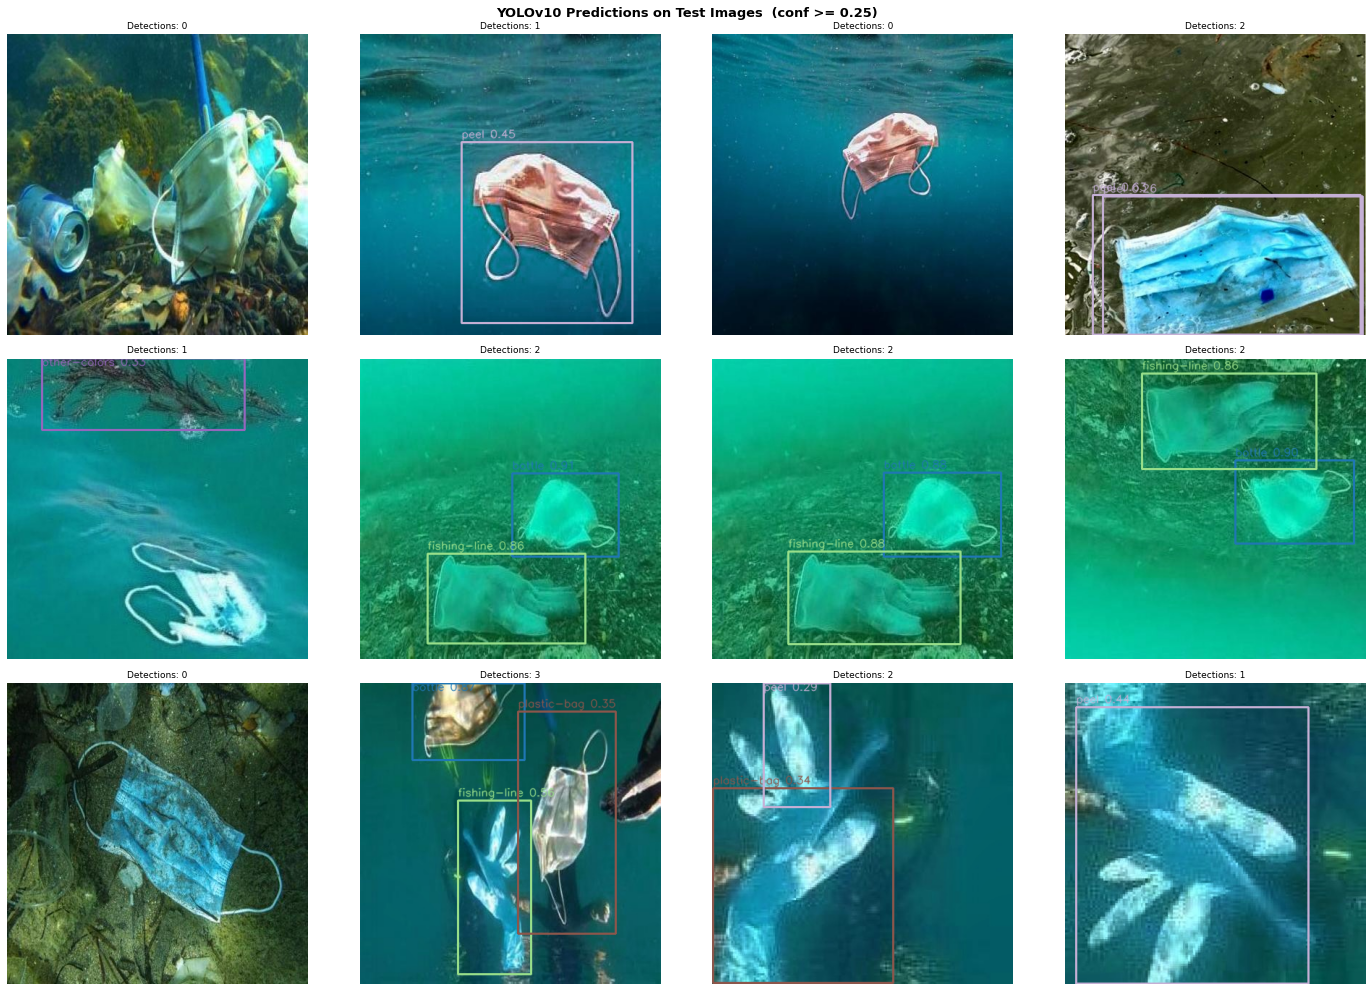

In [16]:
CONF_THRESH = 0.25
IOU_THRESH  = 0.45

# Run batch inference on the test split
test_preds = best_model.predict(
    source   = str(TEST_IMG),
    conf     = CONF_THRESH,
    iou      = IOU_THRESH,
    imgsz    = IMGSZ,
    device   = DEVICE,         # uses GPU on Colab automatically
    save     = True,
    project  = PROJECT,
    name     = RUN_NAME + "_test_preds",
    exist_ok = True,
    stream   = True,
)

# Collect up to 12 results for display
collected = []
for r in test_preds:
    collected.append(r)
    if len(collected) >= 12:
        break

# ── Display predictions ───────────────────────────────────────────────────────
_cmap = matplotlib.colormaps["tab20"]   # compatible with matplotlib ≥3.9

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
fig.suptitle(f"YOLOv10 Predictions on Test Images  (conf >= {CONF_THRESH})",
             fontsize=13, fontweight="bold")

for ax, result in zip(axes.flatten(), collected):
    img_rgb = cv2.cvtColor(result.orig_img.copy(), cv2.COLOR_BGR2RGB)
    boxes   = result.boxes

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cls   = int(box.cls[0])
        conf  = float(box.conf[0])
        label = f"{CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else cls} {conf:.2f}"
        color = tuple(int(c * 255) for c in _cmap(cls / 20.0)[:3])
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img_rgb, label, (x1, max(y1 - 6, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)

    ax.imshow(img_rgb)
    ax.set_title(f"Detections: {len(boxes)}", fontsize=9)
    ax.axis("off")

for ax in axes.flatten()[len(collected):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## Section 11 — Single-Image Waste Detection & Visualisation

### What this cell does

This is a **standalone inference cell** — it can be run immediately after Section 0 and Section 2 without running any training sections. It loads the best available checkpoint, runs inference on a single user-specified image, and produces a rich two-panel visualisation plus a console summary table.

### How to Use

1. Set `TEST_IMAGE_PATH` to the full path of the image you want to analyse (e.g. a JPEG from your camera, a screenshot from a video frame, or a test-set image).
2. Optionally adjust `INFER_CONF` and `INFER_IOU` to tune sensitivity.
3. Run the cell.

### Key Variables

| Variable | Default | Purpose |
|---|---|---|
| `TEST_IMAGE_PATH` | *(set by user)* | Full absolute path to the input image |
| `INFER_CONF` | 0.25 | Confidence threshold — lower value detects more objects (including less certain ones) |
| `INFER_IOU` | 0.45 | NMS IoU threshold — lower value removes more overlapping duplicate boxes |

### Checkpoint Auto-Location

The cell tries three locations in priority order:
1. `runs/<RUN_NAME>/weights/best.pt` — primary training output
2. `checkpoints/<RUN_NAME>_best.pt` — rolling backup
3. Most recent timestamped `checkpoints/<RUN_NAME>_best_epoch*.pt` — snapshot fallback

All fallback variables (`DATASET_ROOT`, `RUN_NAME`, `CKPT_BACKUP_DIR`, `CLASS_NAMES`) are also defined inline if the cell is run standalone, ensuring it works without the earlier sections having been executed.

### Output

**Left panel — Annotated image:**  
The original image with colour-coded bounding boxes drawn using `matplotlib.patches.Rectangle` (one consistent colour per class, derived from the `tab20` colourmap). Each box has a label showing `class_name confidence_score` rendered with a semi-transparent background for readability.

**Right panel — Detection count bar chart:**  
A horizontal bar chart showing how many objects of each detected class were found. The mean confidence score for each class is displayed in parentheses next to the bars.

**Console summary table:**  
A text table listing every detected class, the number of instances, and the average confidence — useful for logging or comparison across images.


In [14]:

# ─────────────────────────────────────────────────────────────────────────────
#  STANDALONE CELL — safe to run directly after Section 0 + Section 2
# ─────────────────────────────────────────────────────────────────────────────
import warnings, sys
warnings.filterwarnings("ignore")
from pathlib import Path

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib
import yaml
from ultralytics import YOLO

# ── Fallback path/variable definitions (if Sections 0–6 were skipped) ────────
if "DATASET_ROOT" not in globals():
    DATASET_ROOT = Path("d:/Project/Underwater_garbage")
if "PROJECT" not in globals():
    PROJECT = "d:/Project/runs"
if "RUN_NAME" not in globals():
    RUN_NAME = "yolov10m_underwater_garbage_v2"
if "CKPT_BACKUP_DIR" not in globals():
    CKPT_BACKUP_DIR = Path("d:/Project/checkpoints")

# Auto-load class names from data.yaml if not already in memory
if "CLASS_NAMES" not in globals():
    _dyaml = DATASET_ROOT / "data.yaml"
    if _dyaml.exists():
        with open(_dyaml) as _f:
            _dcfg = yaml.safe_load(_f)
        CLASS_NAMES = (list(_dcfg["names"].values())
                       if isinstance(_dcfg["names"], dict) else _dcfg["names"])
    else:
        raise FileNotFoundError(
            f"data.yaml not found at {_dyaml}.\n"
            "Run Section 0 first, or ensure DATASET_ROOT is correct."
        )

# NC and a flat list of names — works whether CLASS_NAMES is a dict or a list
NC = len(CLASS_NAMES)
_names_list = list(CLASS_NAMES.values()) if isinstance(CLASS_NAMES, dict) else list(CLASS_NAMES)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ══════════════════════════════════════════════════════════════════════════════
#   ↓  SET YOUR IMAGE PATH HERE — change to the full path of your image  ↓
# ──────────────────────────────────────────────────────────────────────────────
TEST_IMAGE_PATH = r"D:\Project\sample_test\uwg_yt-189__fliph_png_jpg.rf.ae44ab85b3fd87c266c8887fe03aa336.jpg"   # ← CHANGE THIS


INFER_CONF = 0.25   # confidence threshold — lower detects more objects
INFER_IOU  = 0.45   # NMS IoU threshold

# ── Validate image path early ─────────────────────────────────────────────────
if not Path(TEST_IMAGE_PATH).exists():
    raise FileNotFoundError(
        f"\nImage not found: {TEST_IMAGE_PATH}\n"
        "Update TEST_IMAGE_PATH in this cell to the correct path."
    )

# ── Auto-locate best trained checkpoint ───────────────────────────────────────
# Priority: 1. runs dir best.pt  2. checkpoints rolling copy  3. latest snapshot
_snap_list  = sorted(CKPT_BACKUP_DIR.glob(f"{RUN_NAME}_best_epoch*.pt"), reverse=True)
_candidates = [
    Path(PROJECT) / RUN_NAME / "weights" / "best.pt",
    CKPT_BACKUP_DIR / f"{RUN_NAME}_best.pt",
    *_snap_list[:1],
]

_infer_best = next((p for p in _candidates if Path(p).exists()), None)

if _infer_best is None:
    raise FileNotFoundError(
        "\nNo trained model found. Checked:\n"
        + "\n".join(f"  • {p}" for p in _candidates)
        + "\n\nMake sure the checkpoints folder is at d:/Project/checkpoints/ "
          "or train the model via Section 7 first."
    )

print(f"Device   : {DEVICE}")
print(f"Model    : {_infer_best}")
print(f"Image    : {TEST_IMAGE_PATH}")
print(f"Classes  : {NC}  ({', '.join(_names_list)})")

# ── Load model and run inference ──────────────────────────────────────────────
_infer_model = YOLO(str(_infer_best))
_results = _infer_model.predict(
    source  = TEST_IMAGE_PATH,
    conf    = INFER_CONF,
    iou     = INFER_IOU,
    imgsz   = 640,
    device  = DEVICE,
    verbose = False,
)
result  = _results[0]
_cmap   = matplotlib.colormaps["tab20"]
img_rgb = cv2.cvtColor(result.orig_img.copy(), cv2.COLOR_BGR2RGB)

# ── Build detection summary ───────────────────────────────────────────────────
_summary: dict = {}   # class_name → {confs, color, cls_id, patches}
for box in result.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    cls   = int(box.cls[0])
    conf  = float(box.conf[0])
    label = _names_list[cls] if cls < len(_names_list) else f"class_{cls}"
    color = _cmap(cls / 20.0)
    rect  = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                               linewidth=2.5, edgecolor=color, facecolor="none")
    _summary.setdefault(label, {"confs": [], "color": color, "cls_id": cls, "patches": []})
    _summary[label]["confs"].append(conf)
    _summary[label]["patches"].append((rect, label, conf, color))

# ── Figure layout ─────────────────────────────────────────────────────────────
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(18, 7),
                                      gridspec_kw={"width_ratios": [1.4, 1]})
fig.suptitle(f"Underwater Waste Detection — {Path(TEST_IMAGE_PATH).name}",
             fontsize=13, fontweight="bold")

# Left: annotated image
ax_img.imshow(img_rgb)
for _cls_info in _summary.values():
    for rect, lbl, conf, color in _cls_info["patches"]:
        ax_img.add_patch(rect)
        # Label text above the box
        rx, ry = rect.get_xy()
        ax_img.text(
            rx, ry - 4, f"{lbl} {conf:.2f}",
            color="white", fontsize=7, fontweight="bold",
            bbox=dict(facecolor=color, alpha=0.7, pad=1, edgecolor="none"),
            clip_on=True,
        )
ax_img.set_axis_off()
ax_img.set_title(
    f"{len(result.boxes)} detection(s)  |  conf≥{INFER_CONF}",
    fontsize=10,
)

# Right: detection count bar chart
if _summary:
    _bar_labels = list(_summary.keys())
    _bar_counts = [len(v["confs"]) for v in _summary.values()]
    _bar_colors = [v["color"] for v in _summary.values()]
    _bar_means  = [float(np.mean(v["confs"])) for v in _summary.values()]

    _y = np.arange(len(_bar_labels))
    _bars = ax_bar.barh(_y, _bar_counts, color=_bar_colors, edgecolor="white", linewidth=0.5)
    ax_bar.set_yticks(_y)
    ax_bar.set_yticklabels(_bar_labels, fontsize=9)
    ax_bar.set_xlabel("Count")
    ax_bar.set_title("Detections per class\n(mean conf in parentheses)", fontsize=10)
    ax_bar.invert_yaxis()
    for bar, mean_conf in zip(_bars, _bar_means):
        ax_bar.text(
            bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"({mean_conf:.2f})", va="center", ha="left", fontsize=8,
        )
    ax_bar.set_xlim(0, max(_bar_counts) * 1.25 + 1)
    ax_bar.grid(axis="x", alpha=0.3)
else:
    ax_bar.text(0.5, 0.5, "No detections above\nconfidence threshold",
                ha="center", va="center", fontsize=12, transform=ax_bar.transAxes)
    ax_bar.set_axis_off()

plt.tight_layout()
plt.show()

# ── Console summary ───────────────────────────────────────────────────────────
print(f"\n{'─'*55}")
print(f"  Detections : {len(result.boxes)}  (conf≥{INFER_CONF}, IoU≤{INFER_IOU})")
print(f"{'─'*55}")
for cls_name, info in sorted(_summary.items(), key=lambda x: -len(x[1]["confs"])):
    mean_c = float(np.mean(info["confs"]))
    print(f"  {cls_name:<25s}  count={len(info['confs'])}   mean_conf={mean_c:.3f}")
print(f"{'─'*55}")


Device   : cpu
Model    : d:\Project\runs\yolov10m_underwater_garbage_v2\weights\best.pt
Image    : D:\Project\sample_test\uwg_yt-189__fliph_png_jpg.rf.ae44ab85b3fd87c266c8887fe03aa336.jpg
Classes  : 15  (bottle, can, cap, cigarette, cup, fishing-line, glove, mask, other-colors, peel, plastic-bag, plastic-box, plastic-jar, plastic-gloves, unknown)


<Figure size 1800x700 with 2 Axes>


───────────────────────────────────────────────────────
  Detections : 2  (conf≥0.25, IoU≤0.45)
───────────────────────────────────────────────────────
  plastic-bag                count=1   mean_conf=0.527
  peel                       count=1   mean_conf=0.358
───────────────────────────────────────────────────────


## Section 12 — Gradio Interactive Web Interface

### What this section does

This section launches a **browser-based interactive demo** using [Gradio](https://www.gradio.app/). Instead of editing `TEST_IMAGE_PATH` in a code cell and re-running it, you get a point-and-click web UI that accepts any uploaded image and immediately displays annotated detections — making it easy to test the model on new images without touching any code.

### Setup (run once)

The **install cell** runs `pip install gradio` inside the active virtual environment. Gradio and its dependencies (~150 MB) are downloaded only once; subsequent runs skip this step if Gradio is already installed.

### How the Interface Works

#### Model Loading (at cell start)

The same checkpoint-priority logic used in Section 11 locates the best `.pt` file. The model is loaded once into `_gr_model` when the cell is run — it is **not** reloaded on every inference call, so repeated uploads are fast.

Class names and device (`cuda` or `cpu`) are also resolved once during startup.

#### `detect()` Function

This is the core inference function called by Gradio every time an image is uploaded or the Detect button is clicked. It:

1. Receives a NumPy `uint8` RGB array from Gradio (Gradio always passes images in RGB).
2. Converts to BGR with `cv2.cvtColor` because YOLO's `predict()` expects OpenCV BGR input.
3. Runs `_gr_model.predict()` with the user-selected confidence and IoU values.
4. Iterates over `result.boxes` and draws bounding boxes and labels directly onto a copy of the image using OpenCV (`cv2.rectangle`, `cv2.putText`, `cv2.FILLED` background rectangles).
5. Builds a plain-text summary table showing total detections, per-class counts, and mean confidence scores.
6. Returns `(annotated_numpy_array, summary_string)` to Gradio.

#### UI Components

| Component | Purpose |
|---|---|
| **Image upload** | Drag-and-drop or file-picker input; triggers detection automatically on upload |
| **Confidence slider** | Controls `conf` parameter (0.05–0.95, default 0.25) — moving left detects more objects |
| **NMS IoU slider** | Controls `iou` parameter (0.1–0.9, default 0.45) — moving left suppresses more overlapping boxes |
| **Detect button** | Manually re-runs inference (e.g. after adjusting a slider without re-uploading) |
| **Output image** | Displays the annotated result with colour-coded bounding boxes |
| **Detection summary** | Text box showing total detections and a per-class table |

#### Colour Palette

A fixed 20-colour palette (`_PALETTE`) ensures each class always receives the same colour across all images, making results visually consistent and easy to compare.

### Accessing the Interface

`demo.launch(share=False, inbrowser=True)` starts a local web server (default `http://127.0.0.1:7860`) and opens it automatically in your default browser. Set `share=True` to generate a temporary public Gradio link for sharing with others.


In [6]:
# ── Install Gradio (run once) ─────────────────────────────────────────────────
import subprocess, sys
subprocess.run(
    [sys.executable, "-m", "pip", "install", "gradio", "--quiet"],
    check=True,
)
import gradio
print(f"Gradio {gradio.__version__} ready")


Gradio 6.8.0 ready


In [8]:
# ── Gradio Underwater Garbage Detection Interface ─────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import cv2
import yaml
import torch
import numpy as np
from pathlib import Path
import gradio as gr
from ultralytics import YOLO

# ── Resolve model & class names (works standalone or after earlier sections) ──
_gr_project      = globals().get("PROJECT",      "d:/Project/runs")
_gr_run_name     = globals().get("RUN_NAME",     "yolov10m_underwater_garbage_v2")
_gr_ckpt_dir     = Path(globals().get("CKPT_BACKUP_DIR", "d:/Project/checkpoints"))
_gr_dataset_root = Path(globals().get("DATASET_ROOT",    "d:/Project/Underwater_garbage"))

# Locate best checkpoint
_gr_snaps = sorted(_gr_ckpt_dir.glob(f"{_gr_run_name}_best_epoch*.pt"), reverse=True)
_gr_candidates = [
    Path(_gr_project) / _gr_run_name / "weights" / "best.pt",
    _gr_ckpt_dir / f"{_gr_run_name}_best.pt",
    *_gr_snaps[:1],
]
_gr_model_path = next((p for p in _gr_candidates if p.exists()), None)
if _gr_model_path is None:
    raise FileNotFoundError(
        "No trained model checkpoint found.\n"
        "Train the model (Section 7) or place a checkpoint in d:/Project/checkpoints/"
    )

# Load class names
if "CLASS_NAMES" in globals() and globals()["CLASS_NAMES"]:
    _gr_names = (list(CLASS_NAMES.values())
                 if isinstance(CLASS_NAMES, dict) else list(CLASS_NAMES))
else:
    _dyaml = _gr_dataset_root / "data.yaml"
    with open(_dyaml) as _f:
        _dcfg = yaml.safe_load(_f)
    _gr_names = (list(_dcfg["names"].values())
                 if isinstance(_dcfg["names"], dict) else _dcfg["names"])

_gr_device = "cuda" if torch.cuda.is_available() else "cpu"

# Load model once — reused for every inference call
_gr_model = YOLO(str(_gr_model_path))

print(f"Model  : {_gr_model_path}")
print(f"Device : {_gr_device}")
print(f"Classes ({len(_gr_names)}) : {', '.join(_gr_names)}")

# ── Stable colour palette (one colour per class) ──────────────────────────────
_PALETTE = [
    (52,  152, 219), (231,  76,  60), ( 46, 204, 113), (155,  89, 182),
    (241, 196,  15), ( 26, 188, 156), (230, 126,  34), ( 52,  73,  94),
    ( 39, 174,  96), (192,  57,  43), ( 41, 128, 185), (142,  68, 173),
    (243, 156,  18), ( 22, 160, 133), (211,  84,   0), ( 44,  62,  80),
    (127, 140, 141), (210, 180, 140), (100, 149, 237), (255, 127,  80),
]

def _colour(cls_id: int):
    return _PALETTE[cls_id % len(_PALETTE)]


def detect(image: np.ndarray, conf_thresh: float, iou_thresh: float):
    """Run inference and return (annotated_image, summary_text)."""
    if image is None:
        return None, "No image provided."

    # Gradio passes a numpy uint8 RGB array — convert to BGR for YOLO
    img_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    results = _gr_model.predict(
        source  = img_bgr,
        conf    = conf_thresh,
        iou     = iou_thresh,
        imgsz   = 640,
        device  = _gr_device,
        verbose = False,
    )
    result = results[0]
    canvas = image.copy()   # draw on RGB copy

    counts: dict = {}

    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cls_id  = int(box.cls[0])
        conf    = float(box.conf[0])
        name    = _gr_names[cls_id] if cls_id < len(_gr_names) else f"class_{cls_id}"
        r, g, b = _colour(cls_id)

        # Bounding box
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (r, g, b), 2)

        # Label background + text
        label = f"{name}  {conf:.2f}"
        (tw, th), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
        label_y = max(y1 - 4, th + 4)
        cv2.rectangle(canvas,
                      (x1, label_y - th - baseline - 2),
                      (x1 + tw + 4, label_y + baseline - 2),
                      (r, g, b), cv2.FILLED)
        cv2.putText(canvas, label, (x1 + 2, label_y - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

        counts.setdefault(name, []).append(conf)

    # ── Build summary text ────────────────────────────────────────────────────
    if counts:
        total = sum(len(v) for v in counts.values())
        lines = [f"Total detections : {total}\n",
                 f"{'Class':<28} Count   Mean conf",
                 "─" * 46]
        for cls_name, confs in sorted(counts.items(), key=lambda x: -len(x[1])):
            lines.append(f"{cls_name:<28} {len(confs):<7} {np.mean(confs):.3f}")
        summary = "\n".join(lines)
    else:
        summary = "No objects detected above the confidence threshold."

    return canvas, summary


# ── Gradio UI ─────────────────────────────────────────────────────────────────
with gr.Blocks(title="Underwater Garbage Detector", theme=gr.themes.Ocean()) as demo:
    gr.Markdown(
        """
        # 🐠 Underwater Garbage Detector
        Upload an underwater image — the YOLOv10 model will detect and label waste objects with bounding boxes.
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            inp_image = gr.Image(
                label="Input Image",
                type="numpy",
                image_mode="RGB",
            )
            conf_slider = gr.Slider(
                minimum=0.05, maximum=0.95, value=0.25, step=0.05,
                label="Confidence Threshold",
                info="Lower = detects more objects (but more false positives)",
            )
            iou_slider = gr.Slider(
                minimum=0.1, maximum=0.9, value=0.45, step=0.05,
                label="NMS IoU Threshold",
                info="Lower = suppresses overlapping boxes more aggressively",
            )
            run_btn = gr.Button("🔍  Detect", variant="primary")

        with gr.Column(scale=1):
            out_image = gr.Image(label="Detections", type="numpy")
            out_text  = gr.Textbox(
                label="Detection Summary",
                lines=14,
                interactive=False,
            )

    run_btn.click(
        fn      = detect,
        inputs  = [inp_image, conf_slider, iou_slider],
        outputs = [out_image, out_text],
    )
    inp_image.upload(
        fn      = detect,
        inputs  = [inp_image, conf_slider, iou_slider],
        outputs = [out_image, out_text],
    )

demo.launch(share=False, inbrowser=True)


Model  : d:\Project\runs\yolov10m_underwater_garbage_v2\weights\best.pt
Device : cpu
Classes (15) : bottle, can, cap, cigarette, cup, fishing-line, glove, mask, other-colors, peel, plastic-bag, plastic-box, plastic-jar, plastic-gloves, unknown
* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
